# Credit Card Users Churn Prediction

## Problem Statement

### Business Context

The Thera bank recently saw a steep decline in the number of users of their credit card, credit cards are a good source of income for banks because of different kinds of fees charged by the banks like annual fees, balance transfer fees, and cash advance fees, late payment fees, foreign transaction fees, and others. Some fees are charged to every user irrespective of usage, while others are charged under specified circumstances.

Customers’ leaving credit cards services would lead bank to loss, so the bank wants to analyze the data of customers and identify the customers who will leave their credit card services and reason for same – so that bank could improve upon those areas

You as a Data scientist at Thera bank need to come up with a classification model that will help the bank improve its services so that customers do not renounce their credit cards

### Data Description

* CLIENTNUM: Client number. Unique identifier for the customer holding the account
* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then "Attrited Customer" else "Existing Customer"
* Customer_Age: Age in Years
* Gender: Gender of the account holder
* Dependent_count: Number of dependents
* Education_Level: Educational Qualification of the account holder - Graduate, High School, Unknown, Uneducated, College(refers to college student), Post-Graduate, Doctorate
* Marital_Status: Marital Status of the account holder
* Income_Category: Annual Income Category of the account holder
* Card_Category: Type of Card
* Months_on_book: Period of relationship with the bank (in months)
* Total_Relationship_Count: Total no. of products held by the customer
* Months_Inactive_12_mon: No. of months inactive in the last 12 months
* Contacts_Count_12_mon: No. of Contacts in the last 12 months
* Credit_Limit: Credit Limit on the Credit Card
* Total_Revolving_Bal: Total Revolving Balance on the Credit Card
* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)
* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)
* Total_Trans_Amt: Total Transaction Amount (Last 12 months)
* Total_Trans_Ct: Total Transaction Count (Last 12 months)
* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)
* Avg_Utilization_Ratio: Average Card Utilization Ratio

#### What Is a Revolving Balance?

- If we don't pay the balance of the revolving credit account in full every month, the unpaid portion carries over to the next month. That's called a revolving balance


##### What is the Average Open to buy?

- 'Open to Buy' means the amount left on your credit card to use. Now, this column represents the average of this value for the last 12 months.

##### What is the Average utilization Ratio?

- The Avg_Utilization_Ratio represents how much of the available credit the customer spent. This is useful for calculating credit scores.


##### Relation b/w Avg_Open_To_Buy, Credit_Limit and Avg_Utilization_Ratio:

- ( Avg_Open_To_Buy / Credit_Limit ) + Avg_Utilization_Ratio = 1

### **Please read the instructions carefully before starting the project.**
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same.


## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 imbalanced-learn==0.10.1 xgboost==2.0.3 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 imblearn==0.12.0 xgboost==2.0.3 -q --user
# !pip install --upgrade -q threadpoolctl

In [ ]:
# To help with reading and manipulation of data
import numpy as np
import pandas as pd

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# To help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To split the data
from sklearn.model_selection import train_test_split

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

# To preprocess the data for modelling
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

# To build a logistic regression classifier
from sklearn.linear_model import LogisticRegression

# To build a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To build different ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier

# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To tune a model
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# To create a pipeline for production
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector

# To get different performance metrics
import sklearn.metrics as metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import (
        classification_report,
    confusion_matrix,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score,
)

# To suppress warnings
import warnings

warnings.filterwarnings("ignore")

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again*.

## Loading the dataset

In [ ]:
data = pd.read_csv("/content/BankChurners.csv")
# create a copy of the data to avoid any changes to the original data
df = data.copy()
# Display 10 random sample rows of the dataset
df.head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311
6,810347208,Existing Customer,51,M,4,NaN,Married,$120K +,Gold,46,6,1,3,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066
7,818906208,Existing Customer,32,M,0,High School,NaN,$60K - $80K,Silver,27,2,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,5,2,0,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,6,3,3,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144


## Data Overview

The five point summary of all variables


In [ ]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,NaN,NaN,NaN,739177606.333663,36903783.450231,708082083.0,713036770.5,717926358.0,773143533.0,828343083.0
Attrition_Flag,10127,2,Existing Customer,8500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,10127.0,NaN,NaN,NaN,46.32596,8.016814,26.0,41.0,46.0,52.0,73.0
Gender,10127,2,F,5358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependent_count,10127.0,NaN,NaN,NaN,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
Education_Level,8608,6,Graduate,3128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,9378,3,Married,4687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income_Category,10127,6,Less than $40K,3561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Category,10127,4,Blue,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_on_book,10127.0,NaN,NaN,NaN,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0


Summary of Observations:
Customer Demographics: Most customers are existing, female, graduates, married, with an income below 40k, and holding a blue card.
Age Distribution: Customer ages range from 26 to 73 years, with a median age of 46 years.
Dependents: The number of dependents varies between 0 and 5, with a median of 2.
Months on Book: Customers have been with the bank between 13 and 56 months, with a median of 36 months.
Products Held: The total number of products held by customers ranges from 1 to 6, with a median of 4.
Inactive Months: Customers have been inactive for 0 to 6 months, with an average inactivity of 2 months.
Customer Contact: The number of contacts with the bank within the last 12 months ranges from 0 to 6 times, with a median of 2 times.
Credit Limit: Credit limits range between 1,438.3 and 34,516.0, with a median of 4,549.
Revolving Balance: Total revolving balances range from 0 to 2,517, with a median of 1,276.
Available Credit: The Avg_Open_To_Buy varies between 3 and 34,516.0, with a median of 3,474. The value 3 appears suspicious and requires further investigation.
Transaction Ratios: The ratio of total transaction counts between the 4th and 1st quarters ranges from 0 to 3.397.
Transaction Amount: The total transaction amount varies between 510 and 18,484.0, with a median of 3,899.0.
Transaction Count: The total transaction count ranges from 10 to 139, with a median of 67.
Transaction Ratio: The ratio of the total transaction count between the 4th and 1st quarters varies between 0 and 3.71, with a median of 0.702.
Utilization Ratio: The average utilization ratio varies between 0 and 0.99, with a median of 0.176.
This summary highlights key trends and distributions in the customer data, identifying potential areas for further analysis.

Checking the data types


In [ ]:
data.dtypes

,0
CLIENTNUM,int64
Attrition_Flag,object
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64


Checking for null and duplicate values


In [ ]:
data.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,1519
Marital_Status,749
Income_Category,0
Card_Category,0
Months_on_book,0


There are 1519 null values in the Education_Level variable and 749 null values in the Marital_Status

In [ ]:
data.duplicated().sum()

0

There are no duplicated values in the dataset



Checking the unique values in the categorical variables


In [ ]:
#Observing the unique values in all the object columns
for i in data.columns:
    if data[i].dtype == 'O':
        print(f'The Unique values in {i} are:')
        print(data[i].value_counts(normalize=True))
        print('---------------------')

The Unique values in Attrition_Flag are:
Attrition_Flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64
---------------------
The Unique values in Gender are:
Gender
F    0.529081
M    0.470919
Name: proportion, dtype: float64
---------------------
The Unique values in Education_Level are:
Education_Level
Graduate         0.363383
High School      0.233852
Uneducated       0.172746
College          0.117681
Post-Graduate    0.059944
Doctorate        0.052393
Name: proportion, dtype: float64
---------------------
The Unique values in Marital_Status are:
Marital_Status
Married     0.499787
Single      0.420452
Divorced    0.079761
Name: proportion, dtype: float64
---------------------
The Unique values in Income_Category are:
Income_Category
Less than $40K    0.351634
$40K - $60K       0.176755
$80K - $120K      0.151575
$60K - $80K       0.138442
abc               0.109805
$120K +           0.071788
Name: proportion, dtype: float64
------------



*   Our target variable "Attrition Flag" shows imbalance between the classes 16% Attrited customers VS 83% are existing customers.
All the unique values are ligit except for the "Income_Category" that includes a junk value 'abc' that requires amputation



**Exploratory** **Data** **Analysis** **and** **Insights**
**Univariate** **Analysis**
a. Visualizing the Numerical Data From the five-point summary, the following variables are identified as numerical and continuous: 'CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', and 'Avg_Utilization_Ratio'.

However, since 'CLIENTNUM' is a unique identifier for all records, it has no predictive power and will be excluded from further analysis. For the remaining numerical variables, we will define and apply a function to generate both histograms and boxplots to visualize their distributions and identify any potential outliers.

In [ ]:
#we will define a function to plot the boxplot and histogram for all numerical variables
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
#dropping the clientnum column
df.drop('CLIENTNUM', axis=1, inplace=True)
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
df.reset_index(drop=True)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,Attrited Customer,41,M,2,NaN,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,Attrited Customer,30,M,2,Graduate,NaN,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [ ]:
#extracting the list of numerical variables
numerical = list(df.select_dtypes(include=['int64','float64']).columns)
numerical

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

mean is 46.32596030413745 median is 46.0


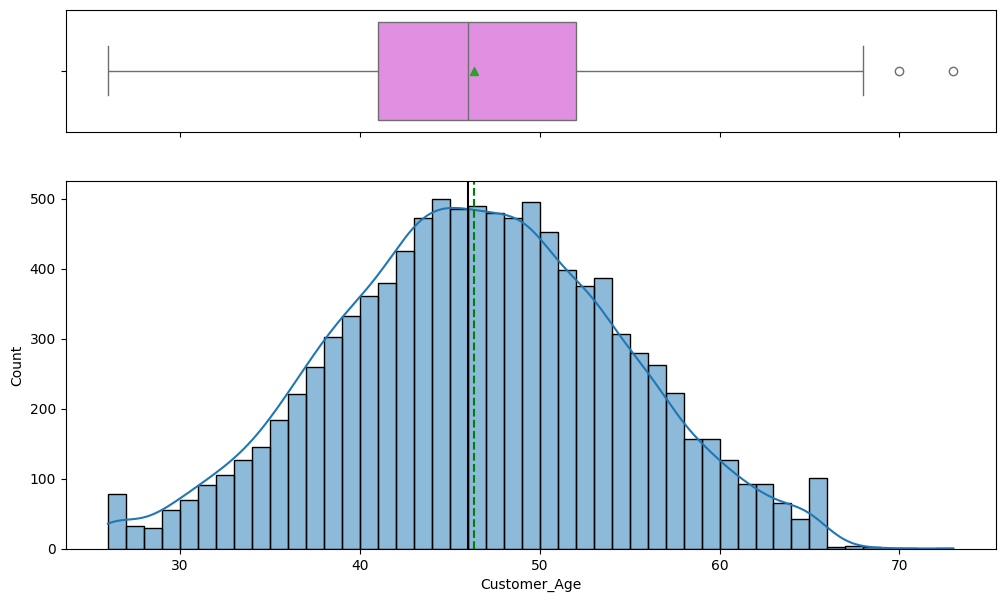

In [ ]:
histogram_boxplot(df, 'Customer_Age', kde=True)
print('mean is' , df['Customer_Age'].mean(), 'median is',  df['Customer_Age'].median())

The customer age vairable is almost normally distributed with a mean very close to the median of approx. 46. There are few outliers at the age 70+ , yet they are realistic values and are consistent with the data.

mean is 2.3462032191172115 median is 2.0


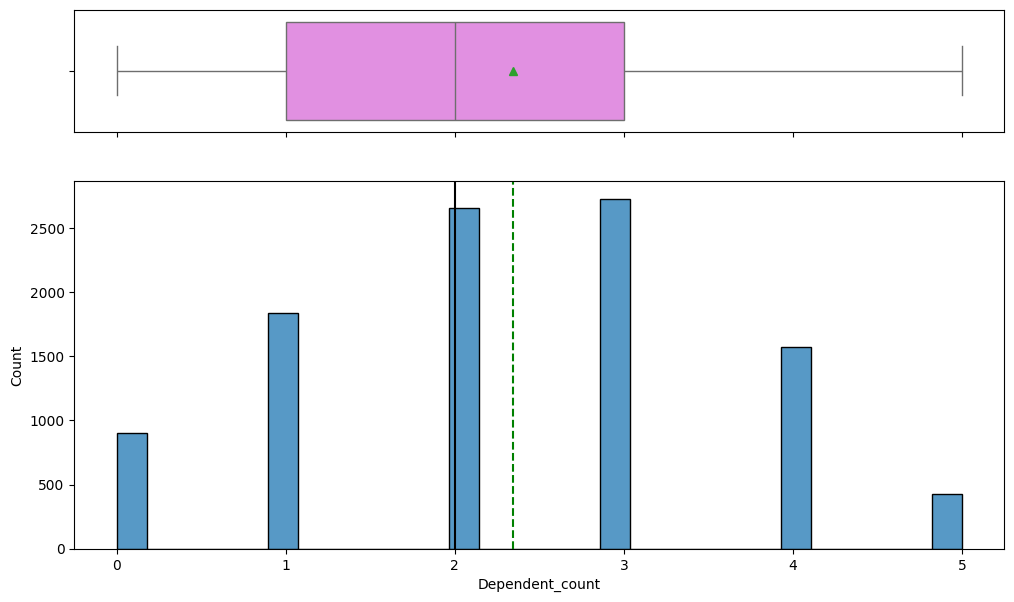

In [ ]:
histogram_boxplot(df, 'Dependent_count')
print('mean is' , df['Dependent_count'].mean(), 'median is',  df['Dependent_count'].median())

*   The Dependent_count variable is almost normally distributed with a slight right skew.
*   The mean mean of 2.3 median of 2.0 are fairly close and there are no outliers observed

mean is 35.928409203120374 median is 36.0
min is 13 max is 56


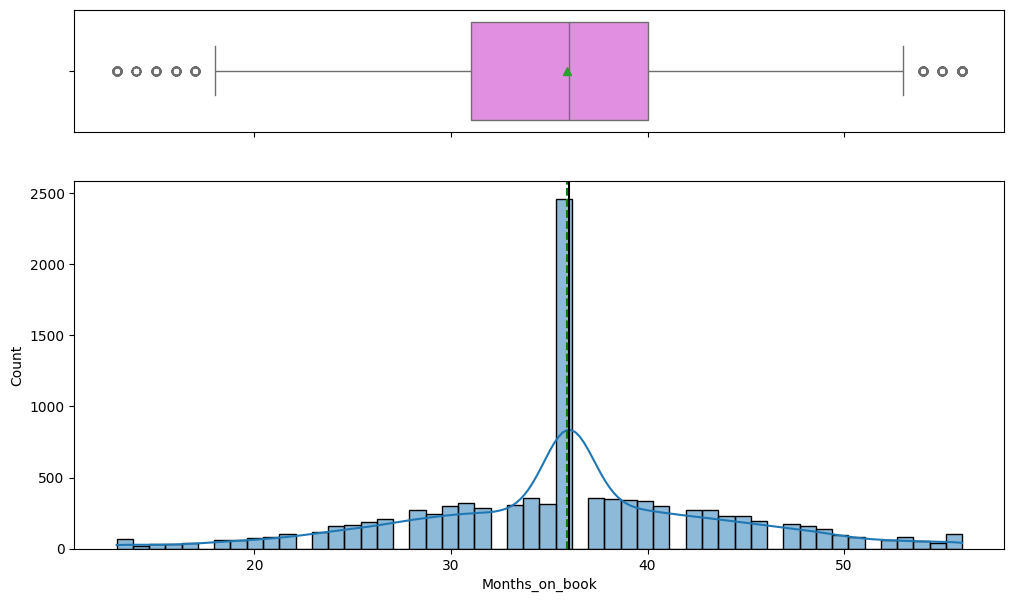

In [ ]:
histogram_boxplot(df, 'Months_on_book', kde=True)
print('mean is' , df['Months_on_book'].mean(), 'median is',  df['Months_on_book'].median())
print('min is' , df['Months_on_book'].min(), 'max is',  df['Months_on_book'].max())



*  The Months_on_book variable also seems normally distributed with very close mean and median valyes of approx 36 months.
*   There are out liers at both skewers yet the min and max values of the variable seem consistent with the data at the minimum Months_on_book value is 13 months (1 year and 1 month) and the max is 56 months (approx. 4.6 years) which seems reasonable.

mean is 3.8125802310654686 median is 4.0


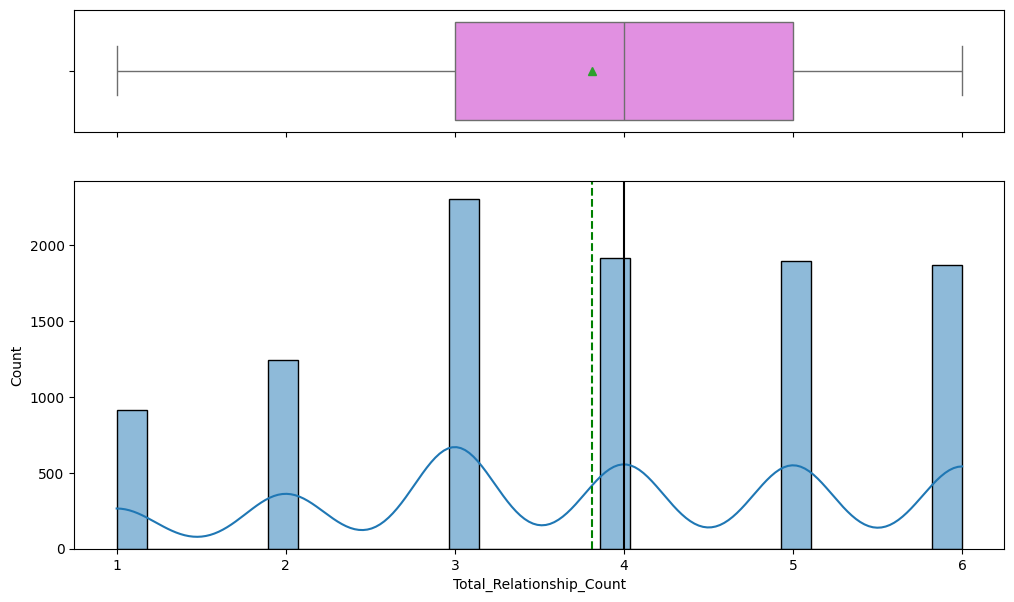

In [ ]:
histogram_boxplot(df, 'Total_Relationship_Count', kde=True)
print('mean is' , df['Total_Relationship_Count'].mean(), 'median is',  df['Total_Relationship_Count'].median())

*   The Total_Relationship_Count shows the majority of customers hold 3 products.

*  The distribution can be approximated to a slightly left skewed distribution with min value 1 and max value 6.
There are no outliers observed.

mean is 2.3411671768539546 median is 2.0


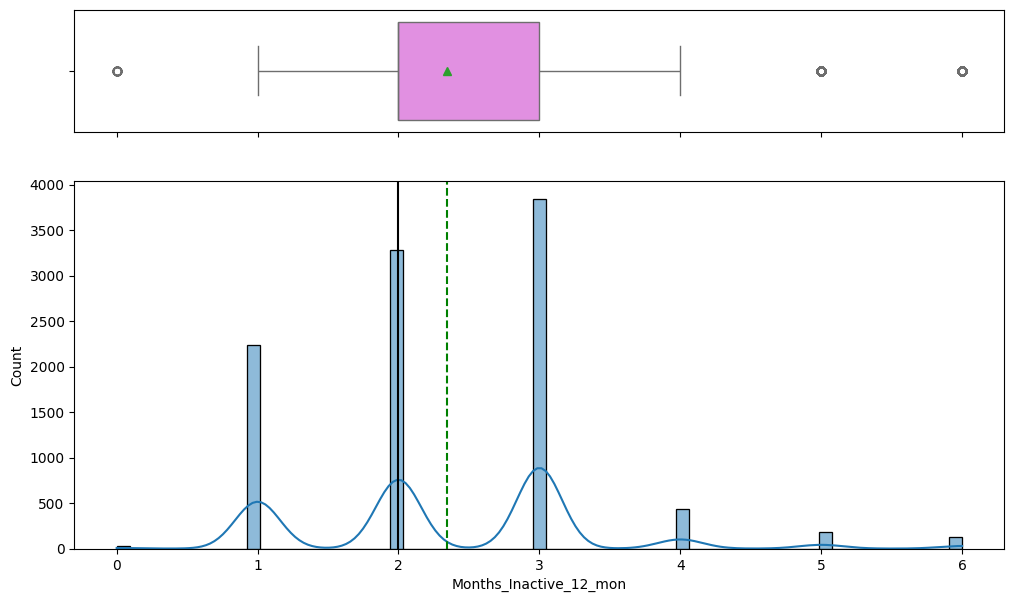

In [ ]:
histogram_boxplot(df, 'Months_Inactive_12_mon', kde=True)
print('mean is' , df['Months_Inactive_12_mon'].mean(), 'median is',  df['Months_Inactive_12_mon'].median())

*   The Months_Inactive_12_mon shows a right skewed distribution with mean and median close in value approx 2 months.

*  There are some outliers at 0 months and beyond 4 months, yet they are realistic values and are consistent with the data


mean is 2.4553174681544387 median is 2.0


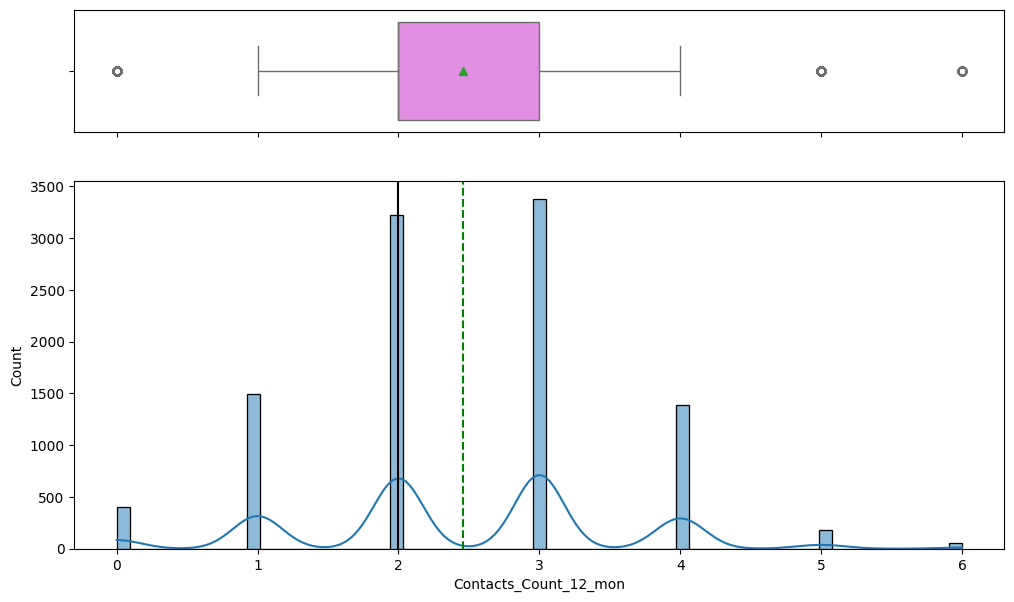

In [ ]:
histogram_boxplot(df, 'Contacts_Count_12_mon', kde=True)
print('mean is' , df['Contacts_Count_12_mon'].mean(), 'median is',  df['Contacts_Count_12_mon'].median())

*   The Contacts_Count_12_mon variable shows a right skewed distribution with mean and median close in value approx 2 times of contact.

*   There are some outliers at 0 times and beyond 4 times, yet they are realistic values and are consistent with the data

mean is 8631.953698034955 median is 4549.0


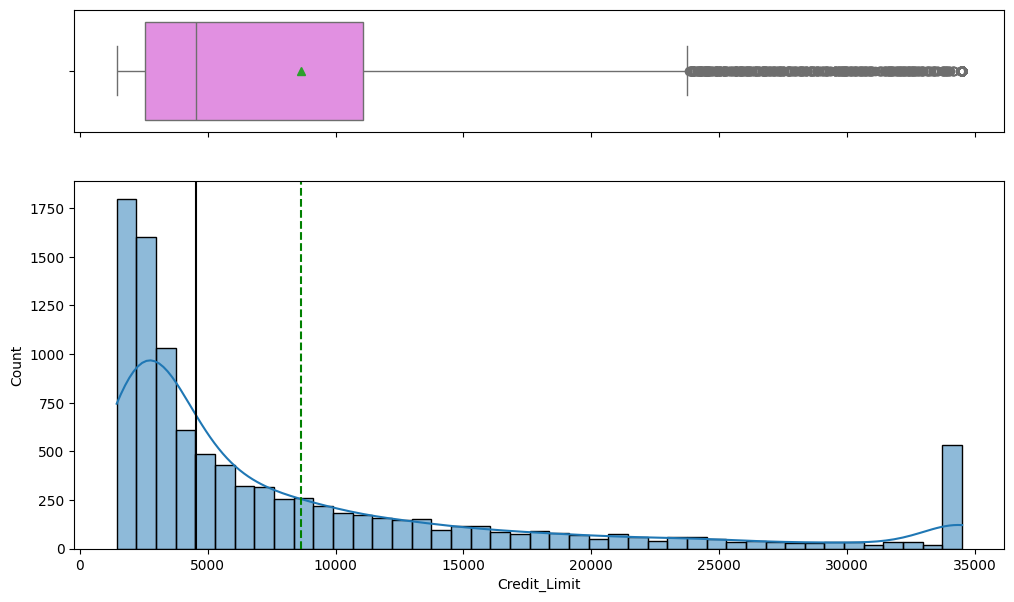

In [ ]:
histogram_boxplot(df, 'Credit_Limit', kde=True)
print('mean is' , df['Credit_Limit'].mean(), 'median is',  df['Credit_Limit'].median())

*  The credit_limit variable shows a heavily right skewed distribution with mean of 8361 abd median of 4549.

*   The box plot shows a high number of outliers beyond the 24,000 mark, yet the outliers seems consistent with the data distribution and realistic values as viewed from the real world.

mean is 1162.8140614199665 median is 1276.0


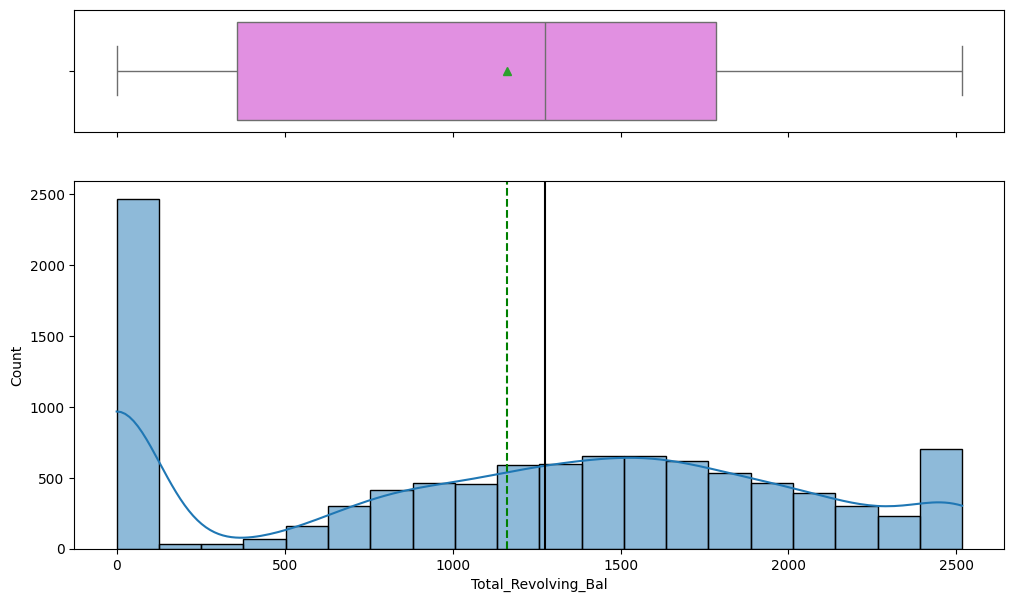

In [ ]:
histogram_boxplot(df, 'Total_Revolving_Bal', kde=True)
print('mean is' , df['Total_Revolving_Bal'].mean(), 'median is',  df['Total_Revolving_Bal'].median())

*   Displaying the Total_Revolving_Bal after displaying the credit_limit variable proves the data records are ligit, as it is realistic for the customers with low credit_limits to have no total_revolving balance on their credit card compared to the customers with high credit limit who keeps a higher total_revolving balance.
*   There are no outliers observed.

mean is 7469.139636614989 median is 3474.0


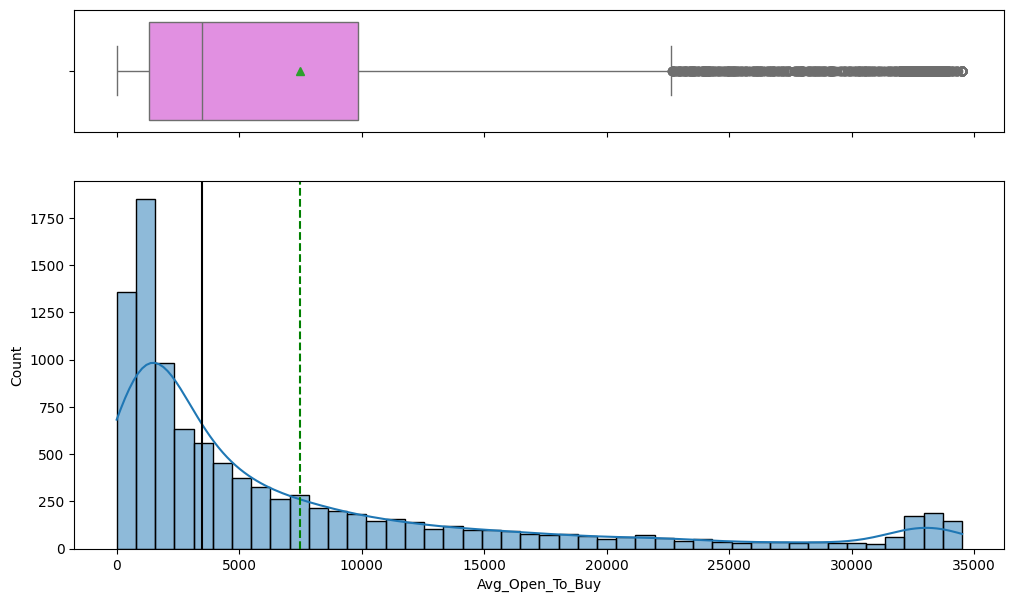

In [ ]:
histogram_boxplot(df, 'Avg_Open_To_Buy', kde=True)
print('mean is' , df['Avg_Open_To_Buy'].mean(), 'median is',  df['Avg_Open_To_Buy'].median())

*   The Avg_Open_To_Buy variable is heavily right skewed with a mean of 7469 and median 3474. It also shows heaving concentration of outliers, yet they do seem consistent with the data.
*   The distribution is also observed to be very close to the credit_limit variable distribution as realistically it makes good sense that those two variables are directly proportional.

mean is 0.7599406536980349 median is 0.736


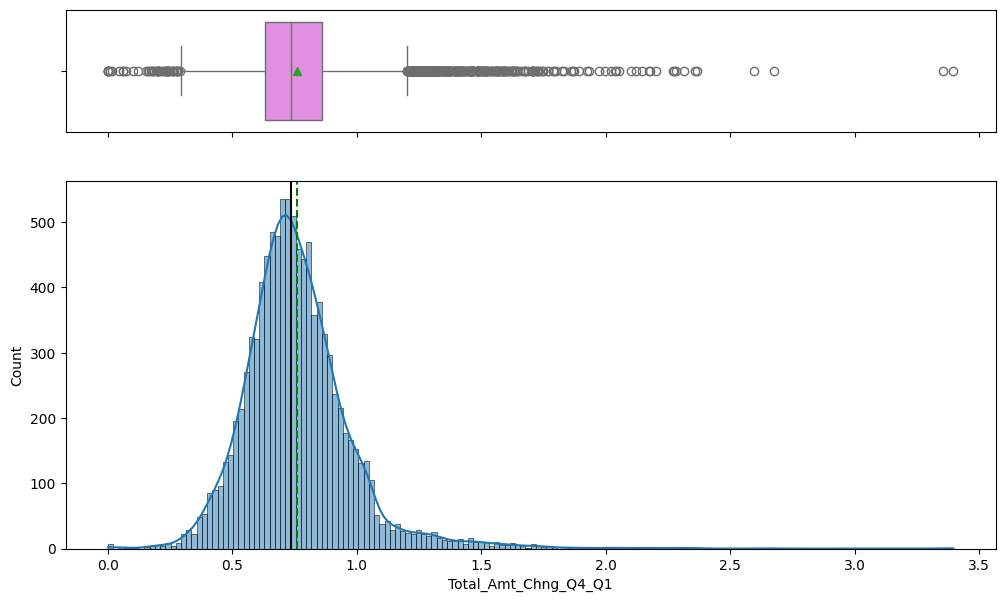

In [ ]:
histogram_boxplot(df, 'Total_Amt_Chng_Q4_Q1', kde=True)
print('mean is' , df['Total_Amt_Chng_Q4_Q1'].mean(), 'median is',  df['Total_Amt_Chng_Q4_Q1'].median())

*   The Total_Amt_Chng_Q4_Q1 variable shows a right skewed distribution with a high number of outlisers beyond the 1.2 mark. The mean and median are yet very close in value to approx 0.73 .
*   The outliers seem ligit as there are many reasons why a customer spending can increase significantly through out the year for example: a job change with a high raise or the end of year bonus.





mean is 0.7122223758269972 median is 0.702


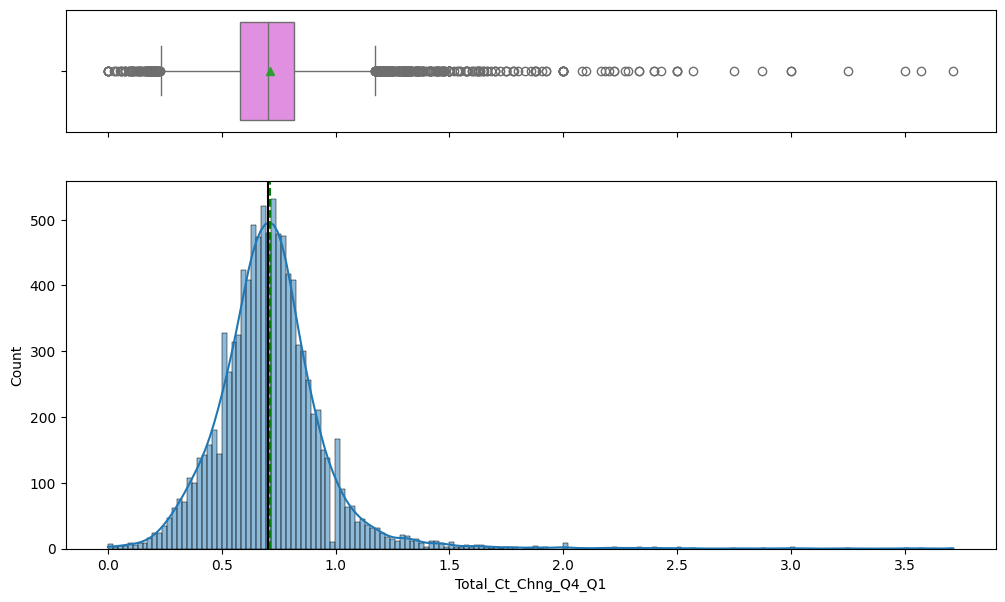

In [ ]:
histogram_boxplot(df, 'Total_Ct_Chng_Q4_Q1', kde=True)
print('mean is' , df['Total_Ct_Chng_Q4_Q1'].mean(), 'median is',  df['Total_Ct_Chng_Q4_Q1'].median())

*   As expected, the Total_Ct_Chng_Q4_Q1 variable is showing a similar distribution to the Total_Amt_Chng_Q4_Q1 which is a right skewed curve with many, yet ligit outliers.

mean is 4404.086303939963 median is 3899.0


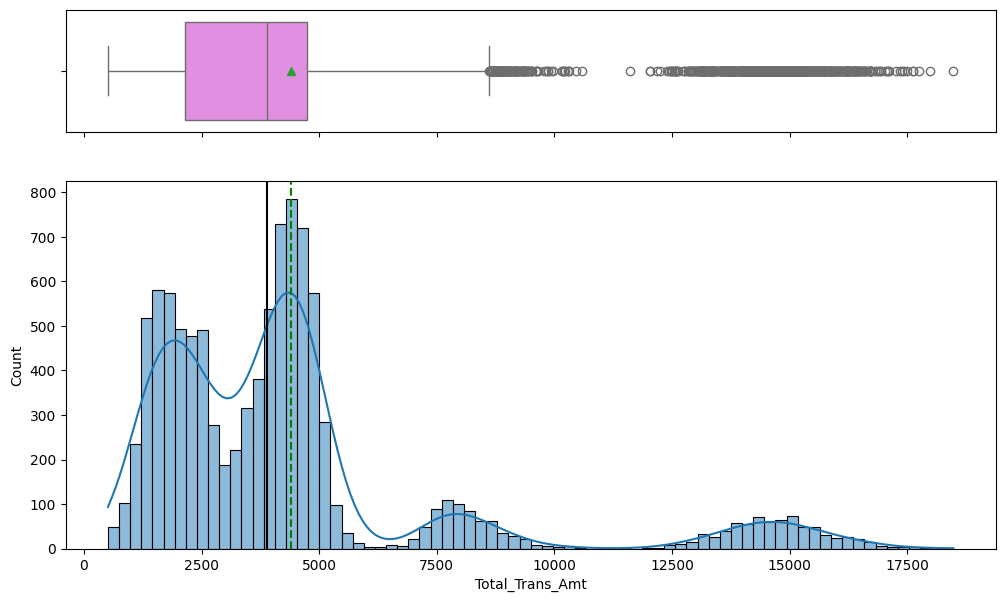

In [ ]:
histogram_boxplot(df, 'Total_Trans_Amt', kde=True)
print('mean is' , df['Total_Trans_Amt'].mean(), 'median is',  df['Total_Trans_Amt'].median())

*   The Total_Trans_Amt variable distribution shows multiple Gausians, which reflects different expenditure of customers of different levels. There are 4 peaks viewed one at approx. 1250 avg, the second one at approx 4,000, the thrist one at approx 7,800 and the final one at approx. 15,000.
*   The recommended action here is to split the data with respect to the gausians and derive a different model for each.

mean is 64.85869457884863 median is 67.0


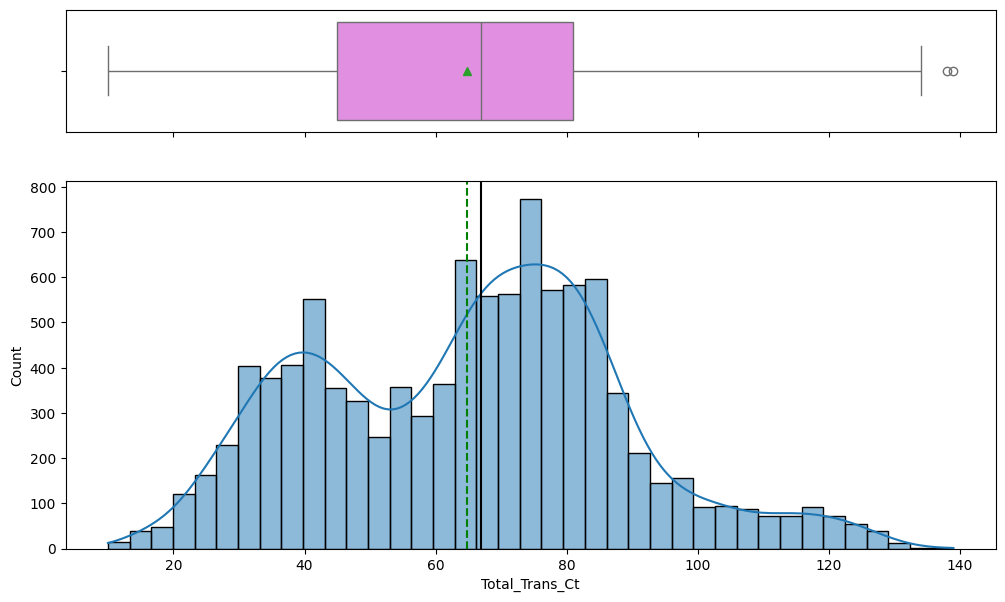

In [ ]:
histogram_boxplot(df, 'Total_Trans_Ct', kde=True)
print('mean is' , df['Total_Trans_Ct'].mean(), 'median is',  df['Total_Trans_Ct'].median())

*   The Total_Trans_Ct variable shows a more normalized distribution compared to the total Total_Trans_Amt variable.
*    It shows two peaks yet they are much smoother than the 4 peaks viewed in the Total_Trans_Amt variable. There are few outliers observed beying the 130 transactions mark, yet they do seem consistent with the data.

mean is 0.2748935518909845 median is 0.176


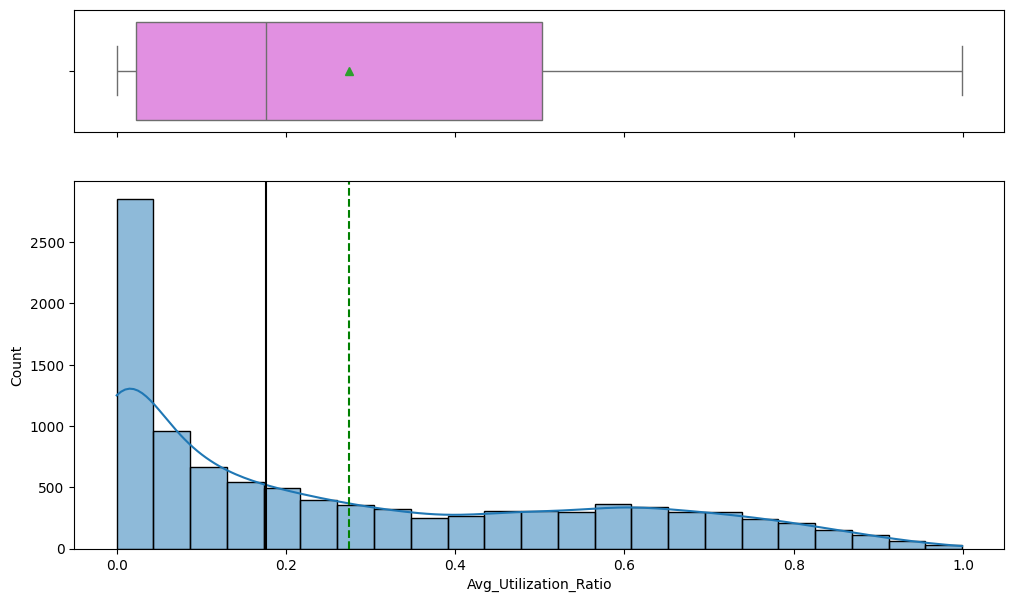

In [ ]:
histogram_boxplot(df, 'Avg_Utilization_Ratio', kde=True)
print('mean is' , df['Avg_Utilization_Ratio'].mean(), 'median is',  df['Avg_Utilization_Ratio'].median())

*   The Average Avg_Utilization_Ratio variable distribution is heavily right skewed showing very high number of customers with 0 utilization rate and very few with 1 utilization rate.
*   This is consistent with the decline observed by the bank of the credit card users.
*   There are no outliers observed.

*   **a. Visualizing the categorical data**

*   From the 5 point summary, it is observed that 'Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category' are categorical in nature, hence we will define and apply a function to plot a labelled barplot for each variable

In [ ]:
#displaying the categorical variables
categorical = list(df.select_dtypes(include=['O']).columns)
categorical

['Attrition_Flag',
 'Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

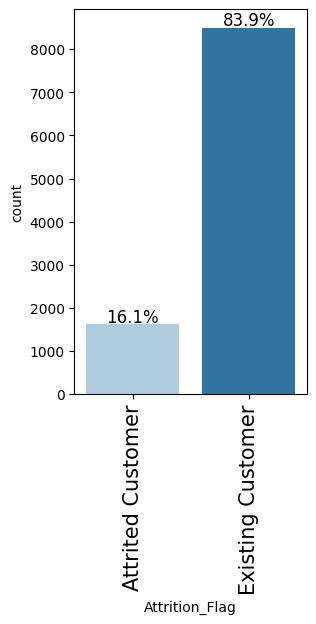

In [ ]:
labeled_barplot(df, 'Attrition_Flag', perc=True)

The target variable shows 16.1% of the customers as Attrited and 83.9% as existing, which as mentioned earlier shows an imbalanace that has to be handled prior to the modelling

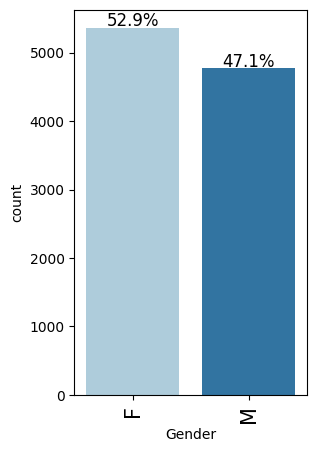

In [ ]:
labeled_barplot(df, 'Gender', perc=True)

As per the five-point summary, the majority of bank clients are Females forming approx 53% of the client base and 47% of the clients are males.


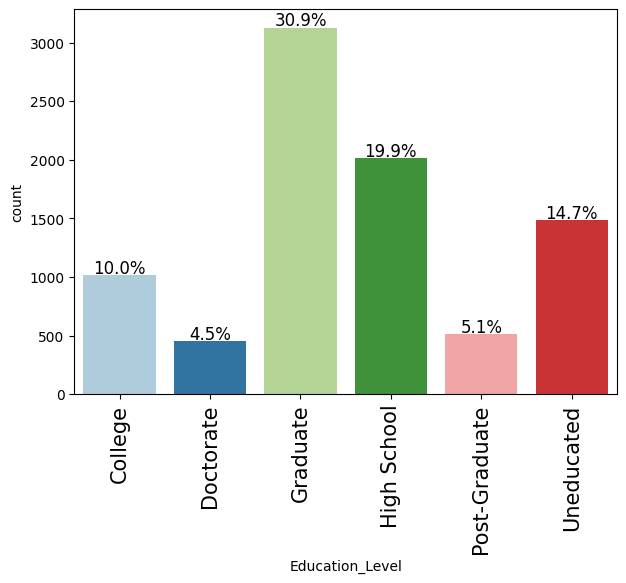

In [ ]:
labeled_barplot(df, 'Education_Level', perc=True)

The majority of customers (30%) are graduates followed by approx 20% high school , followed by 15% uneducated, 10% college graduate, 5.1% post graduate and only 4.5% carry a Doctorate degree

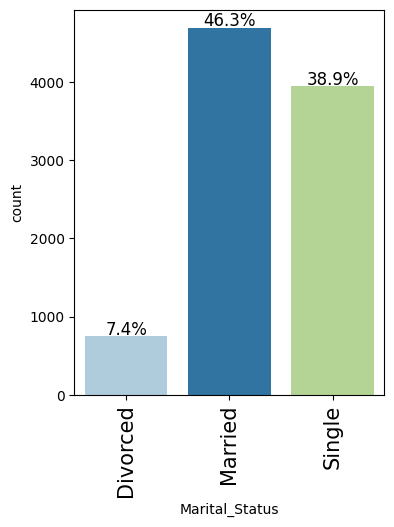

In [ ]:
labeled_barplot(df, 'Marital_Status', perc=True)

The majority (46%) of customers are married, followed by 39% Single and 7.4% Divorced.

As per the five-point summary, the majority of bank clients are Females forming approx 53% of the client base and 47% of the clients are males.

The target variable shows 16.1% of the customers as Attrited and 83.9% as existing, which as mentioned earlier shows an imbalanace that has to be handled prior to the modelling

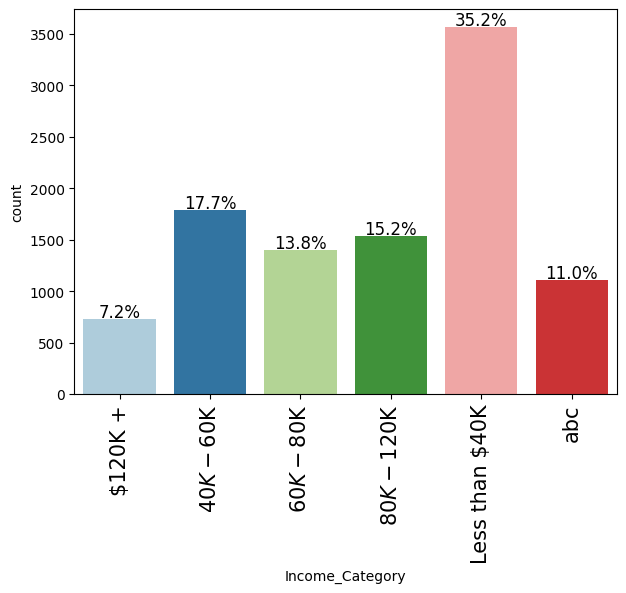

In [ ]:
labeled_barplot(df, 'Income_Category', perc=True)

The majority of customers (35%) belong to the Income_category 'less than $40K) followed by 40K-60K, then 80K - 120K, then 60K-80k and finally only 7.2% belong to the 120K income_category. It is observed that 11% of the records belong to 'abc' category which represents a missing value that requires amputation

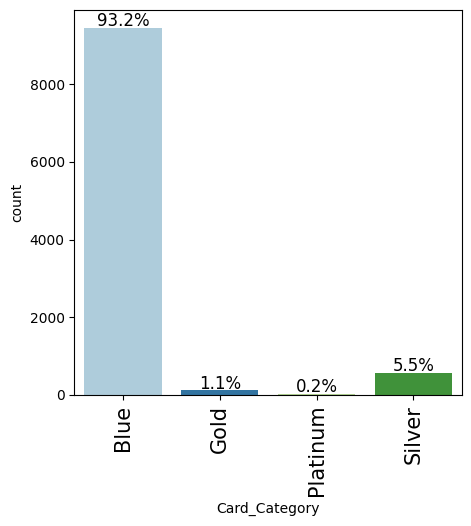

In [ ]:
labeled_barplot(df, 'Card_Category', perc=True)

The majority of customers 93% carry the Blue card followed by 5.5% carrying the silver, 1.1% carrying the Gold and only 0.2% carrying the platinum card.

**Bivariate analysis**

*   After analysing the Categorical and Numerical variables separatly, let us explore how the variables are linked to each other. Hence, we will start by a heatmap followed by a pair plot.

In [ ]:
df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

**Creating a Heatmap**

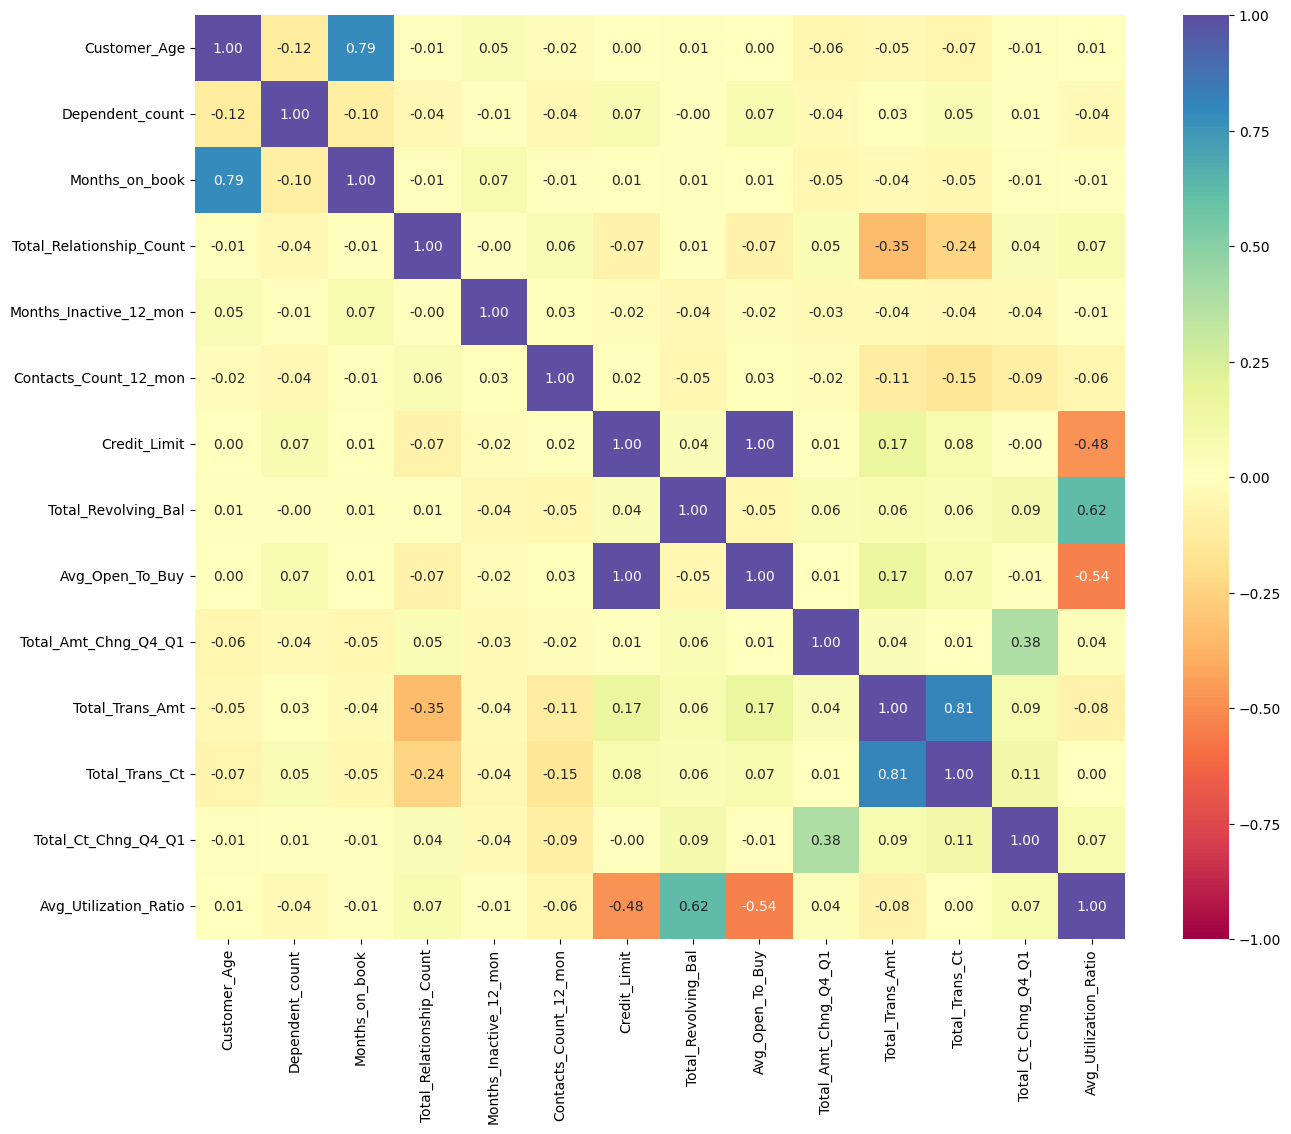

In [ ]:
Selected_Col=['Customer_Age', 'Dependent_count',
              'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
              'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
              'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
              'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
corr_matrix = df[Selected_Col].corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt='0.2f', cmap="Spectral")
plt.show()

In [ ]:
#derving the correlation table
# No period before the DataFrame column selection
df[['Customer_Age', 'Dependent_count','Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon','Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Revolving_Bal','Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt','Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio']].corr()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
Customer_Age,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114
Dependent_count,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135
Months_on_book,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541
Total_Relationship_Count,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663
Months_Inactive_12_mon,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503
Contacts_Count_12_mon,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471
Credit_Limit,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965
Total_Revolving_Bal,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022
Avg_Open_To_Buy,0.001151,0.068291,0.006732,-0.072601,-0.016605,0.025646,0.995981,-0.047167,1.000000,0.007595,0.165923,0.070885,-0.010076,-0.538808
Total_Amt_Chng_Q4_Q1,-0.062042,-0.035439,-0.048959,0.050119,-0.032247,-0.024445,0.012813,0.058174,0.007595,1.000000,0.039678,0.005469,0.384189,0.035235


*   A very strong correlation is observed between Credit_Limit and Avg_Open_To_Buy (correlation value = 0.995981).

*  Strong correlations are also found between:

1.   Customer_Age and Months_on_book (correlation value = 0.788912), which is
expected, as older customers tend to have longer relationships with the bank.
2.   Total_Trans_Amt and Total_Trans_Ct (correlation value = 0.807192), which was evident from the univariate analysis.
3.   A moderate correlation is noted between Total_Revolving_Bal and Avg_Utilization_Ratio (correlation value = 0.624022).

In [ ]:
#plotting the pair plot
plt.figure(figsize=(15,15))
sns.pairplot(df, hue="Attrition_Flag", diag_kind='kde')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

*   The Credit_Limit and Avg_Open_To_Buy variables are highly collinear, so to avoid redundancy, we will drop one of them. In the preprocessing step, the Avg_Open_To_Buy variable will be removed.

*   Due to the class imbalance in the target variable, it is challenging to
confidently assess the predictive strength of the features in this classification problem. However, from the diagonal of the pair plot, we observe the following:

1.   Total_Trans_Ct and Total_Trans_Amt exhibit a varying distribution across both classes, with some overlap. Nevertheless, we can infer that these features have moderate predictive power, as the number of attrited customers significantly decreases as Total_Trans_Ct increases.
2. Similarly, the Average_Utilization_Ratio shows a pattern where the number of attrited customers decreases as Average_Utilization_Ratio increases, indicating moderate predictive power.
3. The Total_Revolving_Balance also shows a slight but noticeable predictive ability, as the number of attrited customers decreases as Total_Revolving_Balance increases.

**Exploring the relationship between Attrition_Flag and Numerical variables**

We will start by deriving the medians (since most variables showed skeweness) of all numerical value columns in terms of Attrited and Existing customers



In [ ]:
df.groupby(["Attrition_Flag"])[numerical].median()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
Attrition_Flag,,,,,,,,,,,,,,
Attrited Customer,47.0,2.0,36.0,3.0,3.0,3.0,4178.0,0.0,3488.0,0.701,2329.0,43.0,0.531,0.000
Existing Customer,46.0,2.0,36.0,4.0,2.0,2.0,4643.5,1364.0,3469.5,0.743,4100.0,71.0,0.721,0.211


For easier interpretation of the relationships, we will plot the medians of all numerical variables with respect to the Attrition_flag. Since there are 14 numerical variables with different mean values, we will divide the Numerical list into 3 groups: low values, Medium Values and High Values. We shall then plot for each group set a bar plot

In [ ]:
#defining the 3 different numerical variable groups with respect to mean values
ratio_vals = ['Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio']
numerical_low_vals = ['Dependent_count', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon']

numerical_med_vals = ['Customer_Age','Months_on_book', 'Total_Trans_Ct']
numerical_high_vals = ['Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy','Total_Trans_Amt']

<Figure size 12000x6000 with 0 Axes>

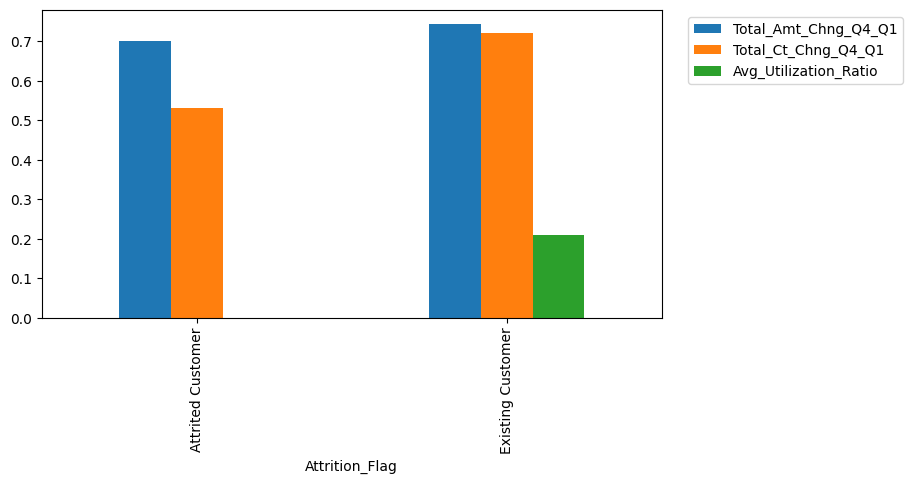

<Figure size 12000x6000 with 0 Axes>

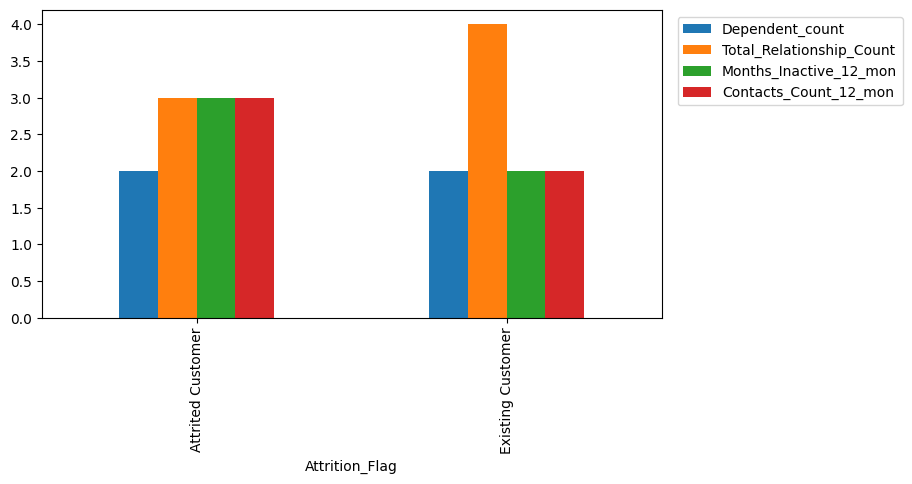

<Figure size 12000x6000 with 0 Axes>

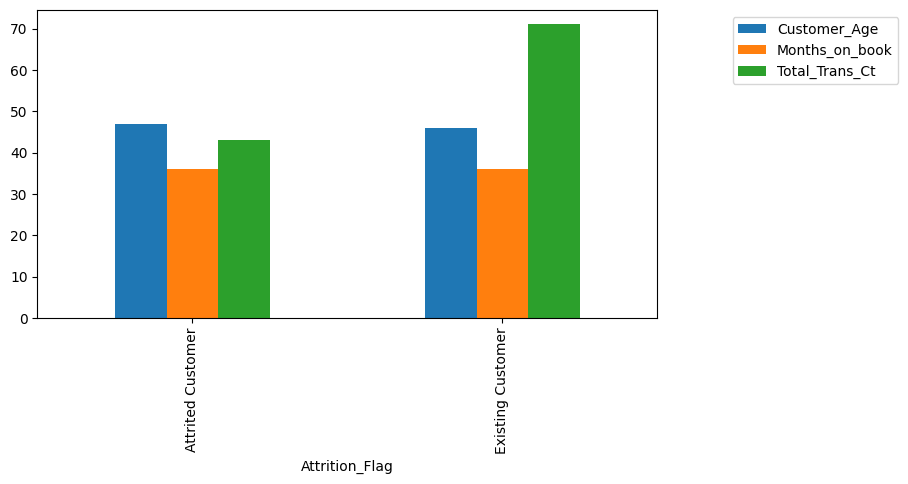

<Figure size 12000x6000 with 0 Axes>

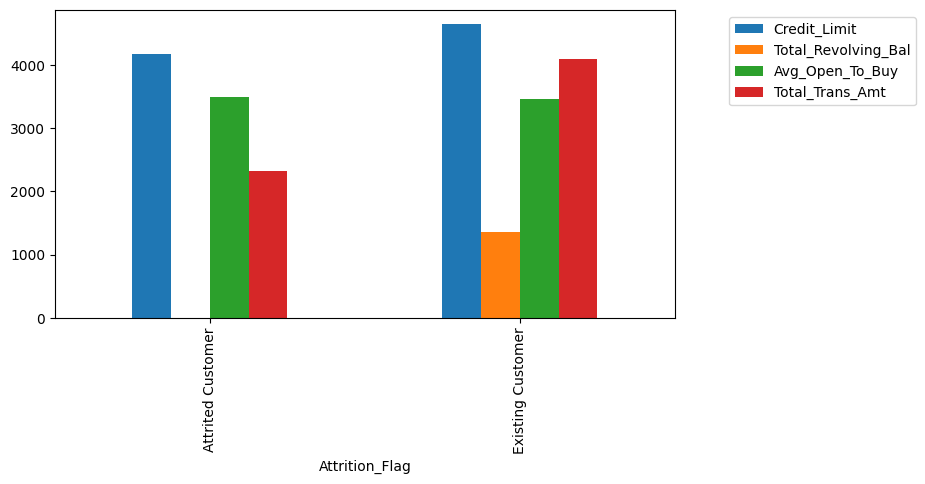

In [ ]:
#plotting the numerical variable means with respect to the Attrition_flag
numeric_list = [ratio_vals,numerical_low_vals,numerical_med_vals,numerical_high_vals]
for i in numeric_list:
    plt.figure(figsize=(120,60))
    (df.groupby(["Attrition_Flag"])[i].median()).plot(kind="bar", figsize=(8, 4), stacked=False)
    plt.legend( bbox_to_anchor=(1.4, 1),loc="best")

Observation: In the below table, we divide the predictors into 3 categories: Weak, Medium and Strong and describe how they vary between the existing and attrited customers. The final interpretation of the predictors strength will be identified at the modeling stage when we derive the importance of the features.

|Prediction Power|Predictor|Description |---|----|---| |Weak|Customer_Age|Almost no variation between existing and attrited customers| |Weak|Dependent_count|Almost no variation between existing and attrited customers| |Weak|Months_on_book|Almost no variation between existing and attrited customers| |Weak|Avg_Open_To_Buy|Almost no variation between existing and attrited customers| |Weak|credit_limit|Almost no variation between existing and attrited customers| |Weak|Total_Amt_Chng_Q4_Q1|Almost no variation between existing and attrited customers| ||| |Medium|Total_Relationship_Count|Lower count observed for attrited customers| |Medium|Contacts_Count_12_mon|Higher count observed for attrited customers| |Medium|Months_Inactive_12_mon|Higher count observed for attrited customers| ||| |Strong|Total_Revolving_Bal|Much lower value observed for attrited customers| |Strong|Total_Trans_Amt|Almost lower by half for attrited customers| |Strong|Total_Trans_Ct|Almost lower by half for attrited customers| |Strong|Total_Ct_Chng_Q4_Q1|Almost lower by 20% for attrited customers| |Strong|Avg_Utilization_Ratio|Almost lower by 20% for attrited customers|



**Exploring the relationship between Attrition_Flag and Categorical variables
**
Since the categorical variables are much less than the numerical variables, the relationship bar plot will be plotted for each variable separately.

In [ ]:
categorical

['Attrition_Flag',
 'Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [ ]:
df[df['Attrition_Flag'] == 'Attrited Customer']['Income_Category'].value_counts(normalize=True)

,proportion
Income_Category,
Less than $40K,0.376152
$40K - $60K,0.166564
$80K - $120K,0.148740
$60K - $80K,0.116165
abc,0.114935
$120K +,0.077443


**Observation:**

*   Weak predictors: Gender and Marital_Status
*   Medium Strength Predictors: Education_Level where the highest ratio of Attired customers are Doctorates and belong to the Income_Category less than $40K
*   Strong Predictors: Card_Category where the highest ratio of Attired customers is within the Platinum card holders.

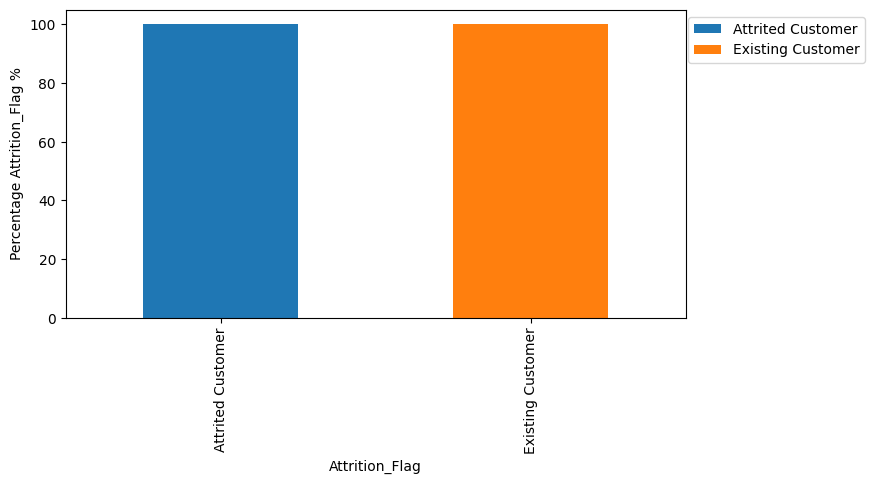

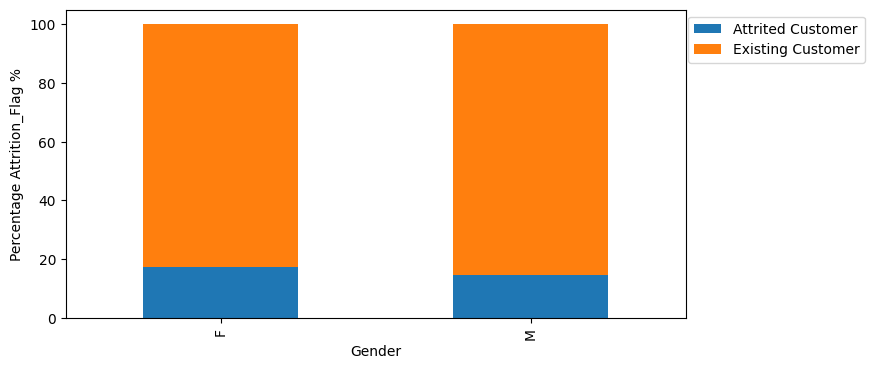

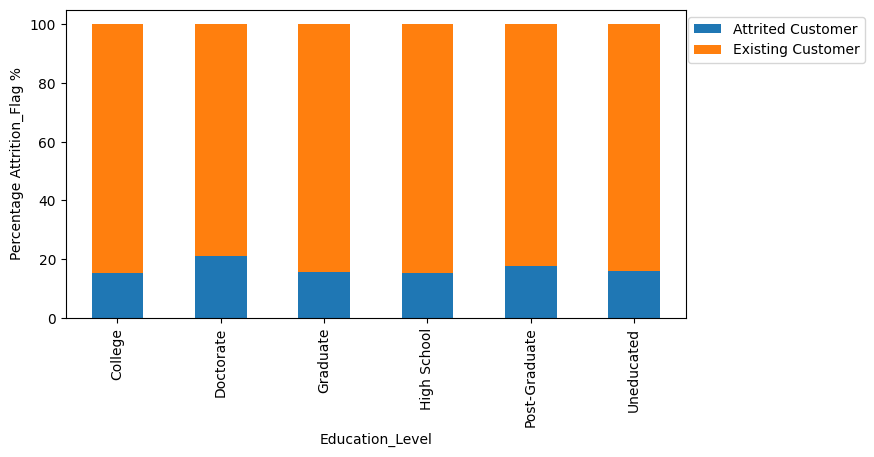

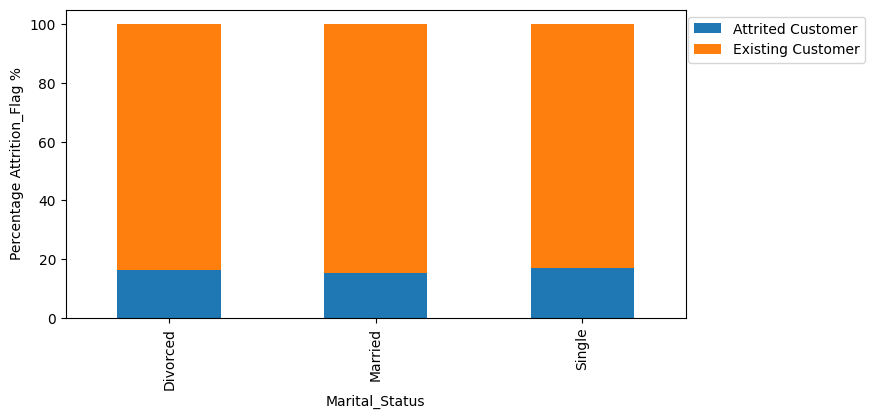

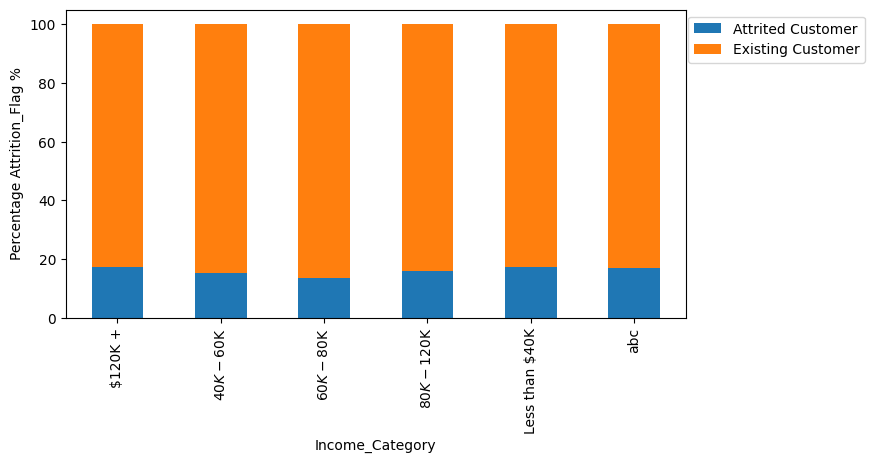

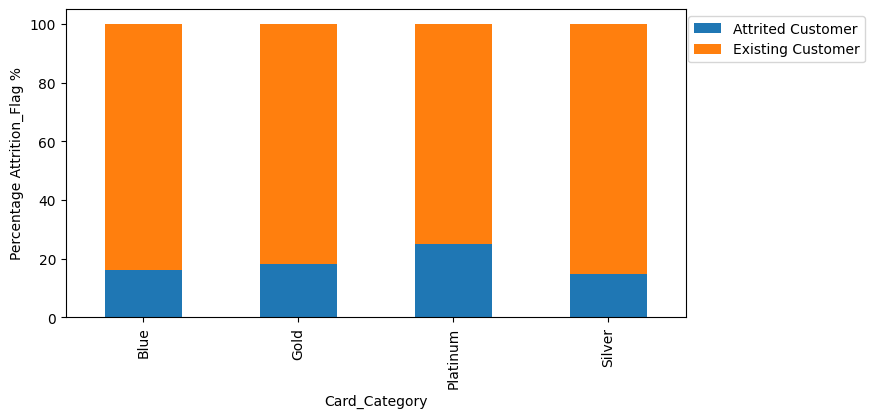

In [ ]:
for i in categorical:
    if i != "Attrited Customer":
        (pd.crosstab(data[i], data["Attrition_Flag"], normalize="index") * 100).plot(
            kind="bar", figsize=(8, 4), stacked=True
        )
        plt.ylabel("Percentage Attrition_Flag %")
        plt.legend( bbox_to_anchor=(1.3, 1),loc="upper right")

**Key meaningful observations on individual variables, relationship between variables and pre-processing required**

*   The Univarate Analysis shows the below common characteristics among customers:
1.   16.1% of the customers as Attrited and 83.9% as existing
2.   53% of the client base are females
3.   53% of the client base are females
4.   93% carry the Blue card
5.   35% belong to the Income_category less than USD 40K
6.   46% of customers are married
7.   30% are graduates

*   The Bivariate Analysis showed:
1.  The Credit_Limit and Avg_Open_To_Buy variables are very strongy correlated
2.  The Total_Trans_Amt and Total_Trans_Ct variables are strongly correlated
3.  The Strong Predictors and their Relation ship between variables and target variable are:

*   Attrited customers have less Total_Revolving_Bal,Total_Trans_Ct,Total_Trans_Amt,Total_Ct_Chng_Q4_Q1 and Avg_Utilization_Ratio than Existing customers

*   Card_Category shows The highest ratio of Attrited customers as Platinum card holders.

*   The preprocessing required:
1. Removing the colinearity: 'Avg_Open_To_Buy' variable shall be dropped
2. Null values amputation for the columns: Education_Level and Marital_Status
3. Missing values amputation in the "Income_category" variable

**Data pre-processing**<br>
**Prepare the data for analysis**<br>
**1- Treating the colinearity**<br>

In [ ]:
#dropping the Avg_Open_To_Buy variable
df.drop('Avg_Open_To_Buy', axis=1, inplace=True)

In [ ]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.0,2517,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,2.175,816,28,2.500,0.000


**2- Splitting the data into Train, Validation and Test**

In [ ]:
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

In [ ]:
# first spliting the data into 2 parts, temporary and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state=1, stratify=y )

# second spliting the data into train and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.25, random_state=1, stratify=y )

print(X_train.shape, X_val.shape, X_test.shape)

(7595, 18) (2532, 18) (2026, 18)


**3- Missing value Treatment**<br>

The adopted approach is applying the KNN Imputer. Hence, the steps followed are:

1. Mapping the missing value columns as they are all categorical
2. Apply the KNN Imputer
3. Apply inverse mapping


In [ ]:
X['Income_Category'].value_counts()

,count
Income_Category,
Less than $40K,3561
$40K - $60K,1790
$80K - $120K,1535
$60K - $80K,1402
abc,1112
$120K +,727


In [ ]:
X.columns

Index(['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
       'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [ ]:
#converting the 'abc' value in the 'Income_Category' to null value
X_train['Income_Category'] = X_train['Income_Category'].replace('abc', np.NaN)
X_val['Income_Category'] = X_val['Income_Category'].replace('abc', np.NaN)
X_test['Income_Category'] = X_test['Income_Category'].replace('abc', np.NaN)

In [ ]:
#create the mapping values
education = {'Graduate':1,'High School':2, 'Uneducated':3, 'College':4,'Post-Graduate':516, 'Doctorate':451}
income = {'Less than $40K':1, '$40K - $60K':2, '$80K - $120K':3, '$60K - $80K':4, '$120K +':5}
marital = {'Married':1,'Single':2, 'Divorced':3}
card = {'Blue':1, 'Silver':2, 'Gold':3, 'Platinum': 4}
gender = {'F':1, 'M':2}

#create a list of the mapping dictionaries to apply the mapping in a for loop
mapping_list=[gender,education,marital,income,card]
categorical = ['Gender','Education_Level','Marital_Status','Income_Category','Card_Category']

#create the mapping for loop
for i in np.arange(0,5):
    X_train[categorical[i]]=X_train[categorical[i]].map(mapping_list[i])
    X_val[categorical[i]]=X_val[categorical[i]].map(mapping_list[i])
    X_test[categorical[i]]=X_test[categorical[i]].map(mapping_list[i])

In [ ]:
imputer = KNNImputer(n_neighbors=5)

In [ ]:
#checking if the mapping was successful on the X_trains set as a sample
X_train.sample(10)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
4655,41,2,3,516.0,NaN,3.0,1,33,3,2,3,7591.0,0,0.648,2302,42,0.500,0.000
6042,53,2,1,NaN,2.0,5.0,1,45,6,2,3,10001.0,0,0.676,4167,74,0.644,0.000
4246,62,1,1,2.0,2.0,1.0,1,36,2,3,4,1930.0,0,0.331,1971,45,0.250,0.000
8011,46,1,3,3.0,1.0,NaN,1,36,2,3,1,2872.0,357,0.869,2629,41,0.640,0.124
2144,56,1,5,451.0,1.0,NaN,1,48,4,2,2,11281.0,2118,0.534,1255,30,0.304,0.188
3226,46,2,1,1.0,3.0,5.0,1,30,6,2,2,2016.0,797,1.108,3772,62,0.879,0.395
7929,46,2,2,1.0,1.0,5.0,1,34,2,3,3,1754.0,894,0.691,4874,79,0.837,0.510
6412,56,1,2,3.0,2.0,NaN,1,47,5,2,1,5261.0,1966,0.672,4448,86,0.792,0.374
9147,40,2,3,NaN,2.0,4.0,1,34,2,2,1,9594.0,2517,0.945,14213,100,0.786,0.262
7497,46,2,4,4.0,1.0,4.0,1,36,4,2,1,1681.0,0,0.464,1953,48,0.500,0.000


In [ ]:
#Fit and transform the train data
X_train=pd.DataFrame(imputer.fit_transform(X_train),columns=X_train.columns)

#Transform the validation data
X_val=pd.DataFrame(imputer.transform(X_val),columns=X_val.columns)

#Transform the test data
X_test=pd.DataFrame(imputer.transform(X_test),columns=X_test.columns)

In [ ]:
#confirming that the imputation was successful and no more null values are present in the dataset
print(X_train.isnull().sum())
print(X_val.isnull().sum())
print(X_test.isnull().sum())

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt            

All missing values have been treated and Moving on to the inverse mapping.

In [ ]:
## creating a function to inverse the encoding
def inverse_map(x,y):
    inv_dict = {v: k for k, v in x.items()}
    X_train[y] = np.round(X_train[y]).map(inv_dict).astype('category')
    X_val[y] = np.round(X_val[y]).map(inv_dict).astype('category')
    X_test[y] = np.round(X_test[y]).map(inv_dict).astype('category')

In [ ]:
mapping_list=[gender,education,marital,income,card]
categorical = ['Gender','Education_Level','Marital_Status','Income_Category','Card_Category']

#create the mapping for loop
for i in np.arange(0,5):
    inverse_map(mapping_list[i],categorical[i])

In [ ]:
#confirming the inverse mapping has been succesful on a sample of the test data
X_test.sample(10)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
1876,41.0,M,2.0,College,Married,$80K - $120K,Blue,33.0,2.0,3.0,3.0,14682.0,2517.0,1.041,8193.0,72.0,0.846,0.171
354,40.0,F,2.0,Doctorate,Single,$40K - $60K,Blue,36.0,6.0,1.0,3.0,2797.0,850.0,0.953,3652.0,64.0,1.370,0.304
507,51.0,M,4.0,NaN,Married,$80K - $120K,Blue,47.0,4.0,3.0,2.0,3861.0,622.0,0.794,4816.0,81.0,0.976,0.161
1011,49.0,M,2.0,High School,Single,$80K - $120K,Silver,40.0,4.0,3.0,2.0,34516.0,1313.0,0.583,15154.0,99.0,0.833,0.038
115,56.0,F,1.0,NaN,Married,Less than $40K,Blue,45.0,4.0,1.0,2.0,3132.0,2230.0,0.780,4412.0,73.0,0.659,0.712
1575,49.0,F,3.0,College,Married,$40K - $60K,Blue,44.0,6.0,2.0,3.0,2578.0,1590.0,0.657,4683.0,89.0,0.618,0.617
729,39.0,F,1.0,High School,Married,Less than $40K,Blue,25.0,2.0,2.0,1.0,2024.0,0.0,0.801,2870.0,36.0,0.500,0.000
568,44.0,F,3.0,College,Single,Less than $40K,Blue,40.0,2.0,1.0,3.0,3269.0,0.0,0.797,5022.0,85.0,0.771,0.000
1895,46.0,F,3.0,Graduate,Single,Less than $40K,Silver,39.0,4.0,3.0,2.0,12222.0,1260.0,1.138,3418.0,78.0,0.733,0.103
1140,26.0,M,0.0,Uneducated,Single,Less than $40K,Blue,36.0,4.0,3.0,4.0,2665.0,1567.0,0.586,2514.0,64.0,0.455,0.588


**4.Encoding categorical variables**

In [ ]:
X_train=pd.get_dummies(X_train,drop_first=True)
X_val=pd.get_dummies(X_val,drop_first=True)
X_test=pd.get_dummies(X_test,drop_first=True)
print(X_train.shape, X_val.shape, X_test.shape)

(7595, 28) (2532, 28) (2026, 28)


After the one-hot-encoding the predictors data frames consists of 28 columns instead of 18

In [ ]:
X_train.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Marital_Status_Married,Marital_Status_Single,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,46.0,4.0,42.0,4.0,0.0,3.0,13376.0,1633.0,0.980,4515.0,63.0,1.172,0.122,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False
1,45.0,2.0,36.0,3.0,4.0,3.0,2918.0,1597.0,0.884,4454.0,76.0,0.900,0.547,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False
2,48.0,4.0,43.0,4.0,2.0,2.0,1438.3,0.0,0.722,2520.0,45.0,0.452,0.000,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False
3,56.0,3.0,46.0,4.0,3.0,2.0,2258.0,0.0,0.617,4803.0,72.0,0.714,0.000,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False
4,55.0,2.0,36.0,5.0,1.0,4.0,1994.0,1175.0,0.794,4455.0,82.0,0.547,0.589,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False


**5. Converting the target variables into two classes 0 and 1**<br>
0:Existing customer<br>
1:Attrited Customer


In [ ]:
y_train = y_train.replace(['Existing Customer','Attrited Customer'],[0,1])
y_val = y_val.replace(['Existing Customer','Attrited Customer'],[0,1])
y_test = y_test.replace(['Existing Customer','Attrited Customer'],[0,1])

**Model building**<br>
**Model evaluation criterion**<br>
Model can make wrong predictions as:<br>
1. redicting a customer will churn in reality the customer would not - Loss of opportunity
2. Predicting a customer will not churn but in reality the customer will churn - Loss of resources

* Which case is more important?<br>
1. If we predict a customer will not churn but in reality the customer will churn.
2. How to reduce this loss i.e need to reduce False Negatives?
3. recall should be maximized, the greater the recall higher the chances of minimizing the false negatives.
4. Defining functions to provide evaluation metrics

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

**Logistic Regression**

In [ ]:
#displaing the ratio of classes in the target variable to set the class_weight in the alogorithm
y_train.value_counts(normalize=True)

,proportion
Attrition_Flag,
0,0.839368
1,0.160632


In [ ]:
#creating a logistic regression model using 'newton-cg' solver for its better performance on large data sets
#Also, class_weight is applied to handle the imbalance in the target variable
model_1 = LogisticRegression(random_state=1, class_weight = {0:0.160632 , 1:0.839368}, solver = 'newton-cg')
log_reg_01 = model_1.fit(X_train, y_train)

In [ ]:
#Fitting the model
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train,y_train)

#Calculating different metrics
dtree_model_train_perf=model_performance(d_tree,X_train,y_train)
print("Training performance:\n",dtree_model_train_perf)
dtree_model_test_perf=model_performance(d_tree,X_test,y_test)
print("Testing performance:\n",dtree_model_test_perf)
#Creating confusion matrix
model_performance(d_tree, X_test, y_test)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.933366  0.784615   0.796875  0.790698


,Accuracy,Recall,Precision,F1
0,0.933366,0.784615,0.796875,0.790698


Model Performance on training set 
   Accuracy    Recall  Precision        F1
0   0.84819  0.854918   0.516592  0.644026


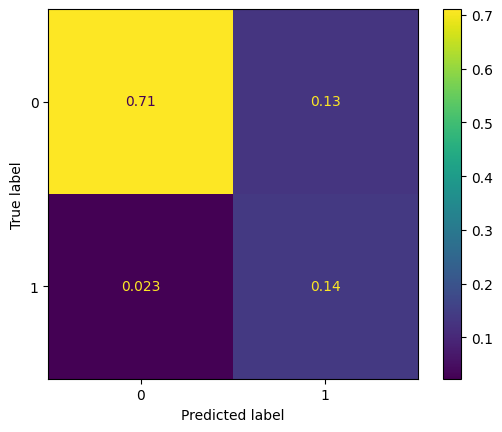

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
perf_log_reg_train_set = model_performance(log_reg_01, X_train, y_train)
print(f'''Model Performance on training set
{perf_log_reg_train_set}''')
cm=confusion_matrix(y_train, log_reg_01.predict(X_train), normalize='all')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

The recall on the train set is fairly good of 85% and the FN in the confusion matrix shows 2.3% only which reflects a very good performance, yet the precision is low but the accuracy is good.

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.846761  0.832924   0.514416  0.636023


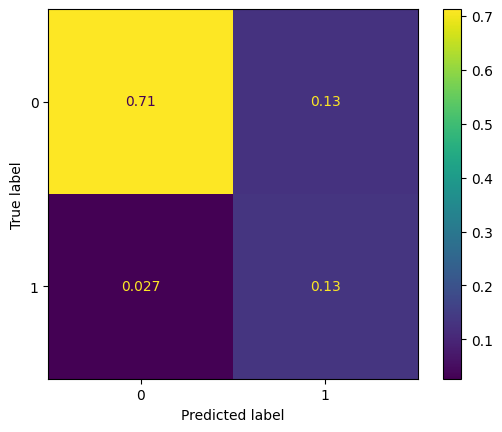

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Evaluate model performance on the validation set
perf_log_reg_val_set = model_performance(log_reg_01, X_val, y_val)
print(f'''Model Performance on validation set
{perf_log_reg_val_set}''')

# Step 1: Generate confusion matrix using validation data
cm = confusion_matrix(y_val, log_reg_01.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()


The recall on the validation set is very close the the recall on the training set which reflects a regularized model

**Decision Tree**<br>

In [ ]:
#creating the decission tree classifier by limiting the max_depth to 5 to reduce the model overfitting
model_2 = DecisionTreeClassifier(random_state=1, max_depth=5)
dTree_1 = model_2.fit(X_train, y_train)

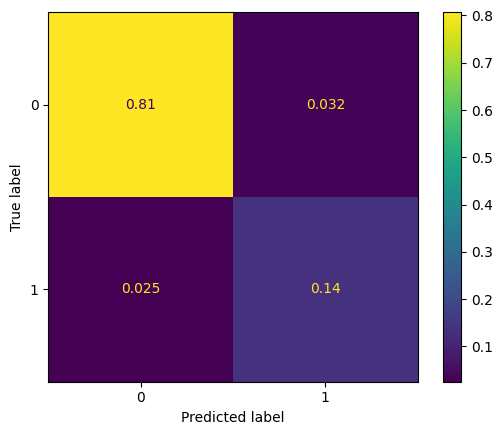

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Assuming dTree_1 is your trained decision tree model, and X_train, y_train are your training data

# Step 1: Generate predictions from the model
y_pred_train = dTree_1.predict(X_train)

# Step 2: Compute the confusion matrix
cm = confusion_matrix(y_train, y_pred_train, normalize='all')  # Pass y_train and y_pred_train

# Step 3: Use ConfusionMatrixDisplay to visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.942462  0.842623   0.807541  0.824709
Model Performance on training set 
   Accuracy    Recall  Precision        F1
0   0.84819  0.854918   0.516592  0.644026


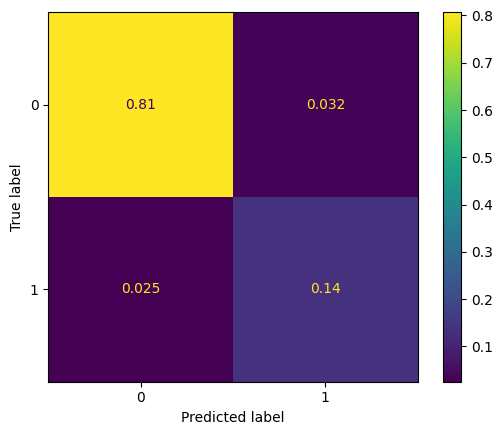

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for Decision Tree
perf_dTree_train_set = model_performance(dTree_1, X_train, y_train)
print(f'''Model Performance on training set
{perf_dTree_train_set}''')

# Model Performance Evaluation on Training Set for Logistic Regression
perf_log_reg_train_set = model_performance(log_reg_01, X_train, y_train)
print(f'''Model Performance on training set
{perf_log_reg_train_set}''')

# Step 1: Generate predictions using the decision tree model on the training data
y_pred_train_dTree = dTree_1.predict(X_train)

# Step 2: Compute the confusion matrix using the actual labels (y_train) and predicted labels (y_pred_train_dTree)
cm = confusion_matrix(y_train, y_pred_train_dTree, normalize='all')

# Step 3: Use ConfusionMatrixDisplay to display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The recall on the train set is fairly good of 84% (slightly less than the logistic regression model) and the FN in the confusion matrix shows 2.5% only which reflects a very good performance. The precision and Accuracy are higher than of the logistic regression model

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.922591  0.776413   0.750594  0.763285


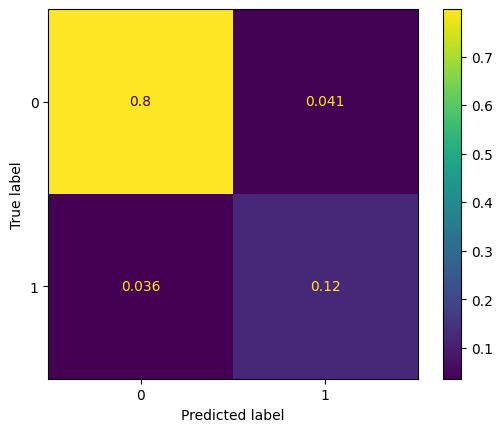

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Decision Tree
perf_dTree_val_set = model_performance(dTree_1, X_val, y_val)
print(f'''Model Performance on validation set
{perf_dTree_val_set}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, dTree_1.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the validation set is worse than on the train set showing a slight overfit in the model compared to the regularized logistic regression model.

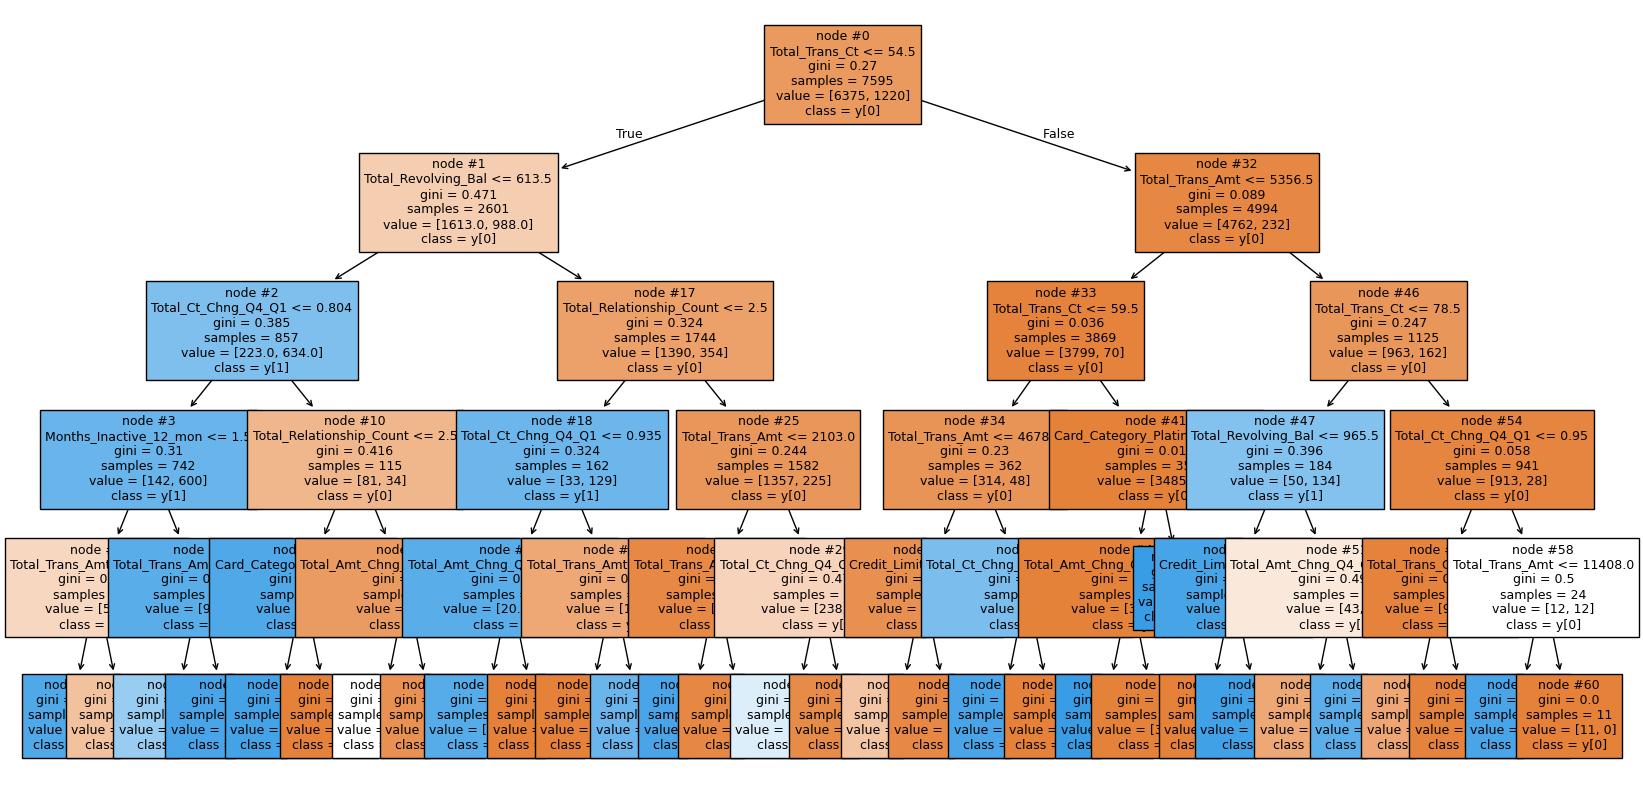

In [ ]:
#As decision trees are useful for data exploration, let us visualize the tree and explore the variables split applied
feature_names = list(X_train.columns)
plt.figure(figsize=(20,10))
tree.plot_tree(dTree_1, feature_names = feature_names, filled=True, fontsize=9,node_ids=True, class_names=True)
plt.show()

The decision tree first split is at the variable Total_Trans_Ct and the second split is created at the Total_Revolving_Bal and the Total_Trans_Amt , then followed by the Total_Relationship_Ct and Total_Ct_Chng_Q1_Q4 wich were all identified as strong predictors in the EDA.

**Adaboost Classifier**<br>

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Assuming model_1 is your base estimator (e.g., decision tree)
model_3 = AdaBoostClassifier(estimator=model_1, random_state=1)

# Fitting AdaBoost model
adaboost_1 = model_3.fit(X_train, y_train)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0   0.84108  0.848361    0.50316  0.631675


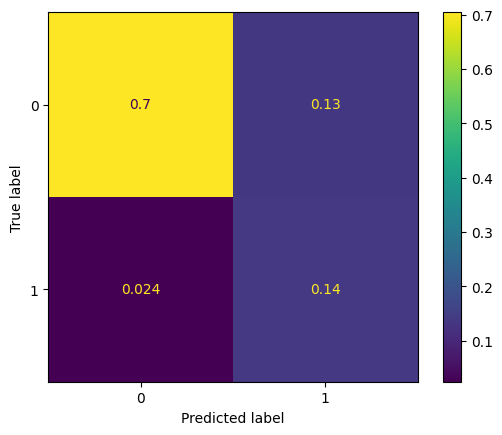

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Assuming `model_performance` is your custom function to evaluate model performance
perf_adaboost_train_set = model_performance(adaboost_1, X_train, y_train)
print(f'''Model Performance on training set
{perf_adaboost_train_set}''')

# Step 1: Generate confusion matrix
cm = confusion_matrix(y_train, adaboost_1.predict(X_train), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance is very close to the logistic regression model yet with a slightly lower recall score and slightly higher FN ratio. Let us explore the performance on the validation set.

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.838073  0.820639   0.497765  0.619666


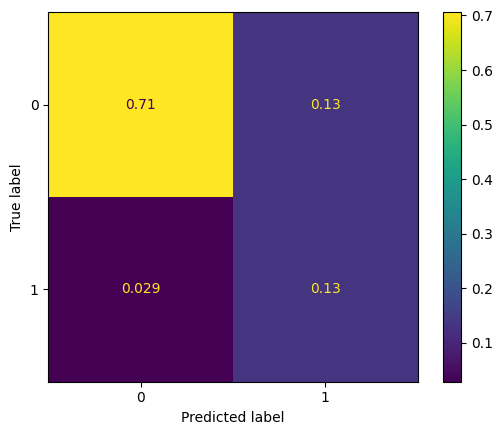

In [ ]:
#model performance evaluation on val set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for AdaBoost
perf_adaboost_val_set = model_performance(adaboost_1, X_val, y_val)
print(f'''Model Performance on validation set
{perf_adaboost_val_set}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, adaboost_1.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

A very good performance is observed on the validation set with no overfitting which means the model is generalized and robust. The performance of the logistic regression model still is better, yet this model presents the second best performing model thus far.

**Gredient Boosting Classifier**<br>

In [ ]:
#creating a Gradient boosting classifier model using the Logistic regression model_1 as its init parameter
model_4 = GradientBoostingClassifier(init = model_1, random_state=1)
gboost_1 = model_4.fit(X_train, y_train)

Model Performance on training set 
   Accuracy    Recall  Precision       F1
0  0.976827  0.896721   0.956294  0.92555


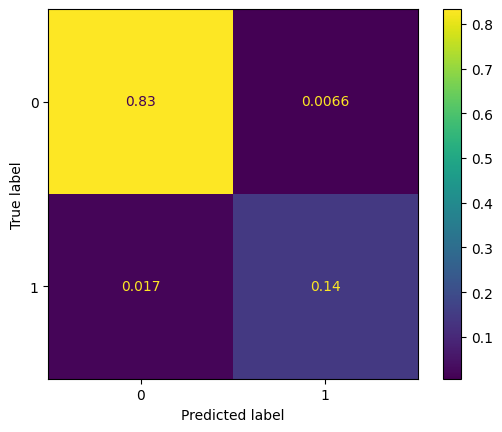

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for Gradient Boosting
perf_gboost_train_set = model_performance(gboost_1, X_train, y_train)
print(f'''Model Performance on training set
{perf_gboost_train_set}''')

# Step 1: Generate the confusion matrix for the training set
cm = confusion_matrix(y_train, gboost_1.predict(X_train), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance is very good, the recall is higher than all recalls derived from adaboost and logistic regression. The FN ratio is also lower, it is yet to confirm if this model is genearlized or not.

Model Performance on validation set 
   Accuracy   Recall  Precision        F1
0  0.968009  0.85258   0.942935  0.895484


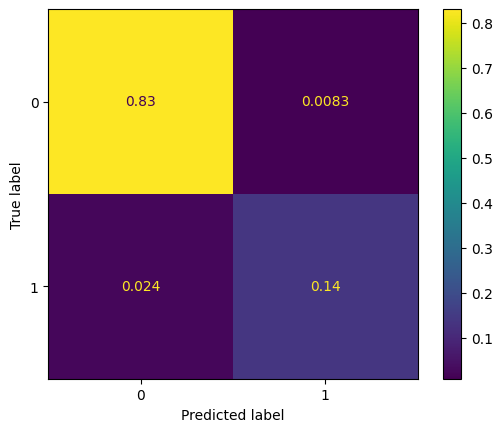

In [ ]:
#model performance evaluation on val set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Gradient Boosting
perf_gboost_val_set = model_performance(gboost_1, X_val, y_val)
print(f'''Model Performance on validation set
{perf_gboost_val_set}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, gboost_1.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the validation set shows that the model is not overfitting, yet it is less generalized when compared to the logistic regression and adaboost models.

**XGBoost Classifier**<br>

In [ ]:
#creating an XGBoost classifier with eval_metric:logloss and max_depth=3 to minimize the overfitting
model_5 = XGBClassifier(random_state=1, eval_metric='logloss', max_depth=3)
xgb_1 = model_5.fit(X_train,y_train)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.989467  0.955738   0.978188  0.966833


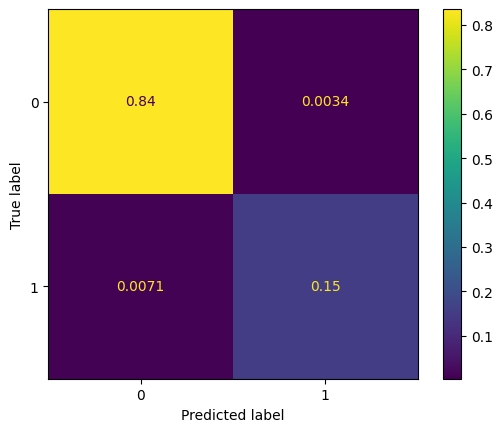

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for XGBoost
perf_xgboost_train_set = model_performance(xgb_1, X_train, y_train)
print(f'''Model Performance on training set
{perf_xgboost_train_set}''')

# Step 1: Generate the confusion matrix for the training set
cm = confusion_matrix(y_train, xgb_1.predict(X_train), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the train set is very good with a high recall score and very small FN Ratio. The Precision and accuracy are also very high.

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.972354  0.884521   0.939948  0.911392


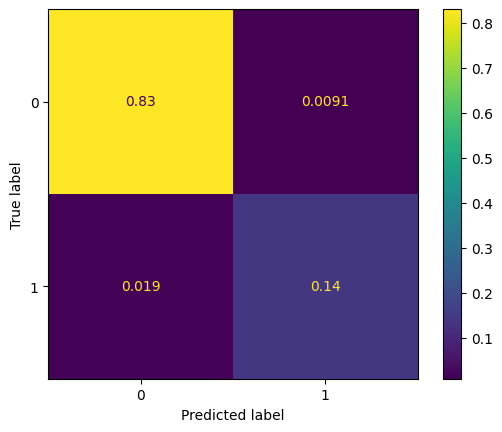

In [ ]:
#model performance evaluation on val set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for XGBoost
perf_xgboost_val_set = model_performance(xgb_1, X_val, y_val)
print(f'''Model Performance on validation set
{perf_xgboost_val_set}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, xgb_1.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The performance dropped on the validation set yet within acceptable limits of slight overfitting. The Accuracy and precision scores dropped very slightly

**Stacking Classifier**<br>

In [ ]:
estimators = [('Logistic regression',log_reg_01), ('Decision Tree',dTree_1), ('Ada Boost',adaboost_1),
              ('XGboost',xgb_1)]

final_estimator = gboost_1

model_6= StackingClassifier(estimators=estimators,final_estimator=final_estimator)

stacking_classifier = model_6.fit(X_train,y_train)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0   0.98894  0.959016   0.971761  0.965347


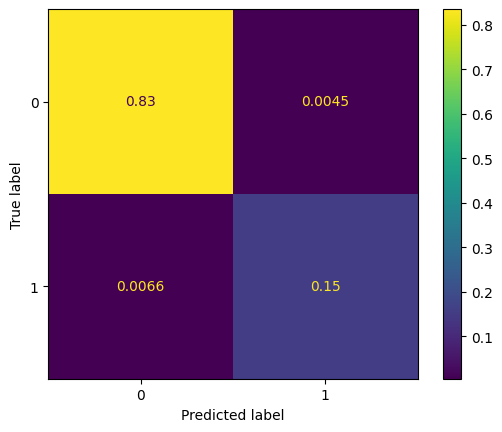

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for Stacking Classifier
perf_stacking_train_set = model_performance(stacking_classifier, X_train, y_train)
print(f'''Model Performance on training set
{perf_stacking_train_set}''')

# Step 1: Generate the confusion matrix for the training set
cm = confusion_matrix(y_train, stacking_classifier.predict(X_train), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model perfirnance on the train set is very close to the XGBoost model with a very good recall, precision and accuracy scores.

Model Performance on validation set 
   Accuracy    Recall  Precision     F1
0  0.969984  0.889435    0.92112  0.905


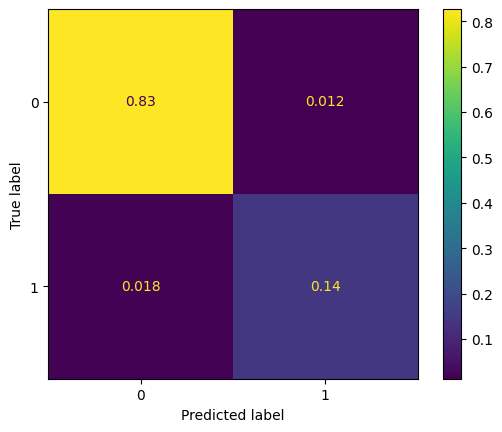

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Stacking Classifier
perf_stacking_val_set = model_performance(stacking_classifier, X_val, y_val)
print(f'''Model Performance on validation set
{perf_stacking_val_set}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, stacking_classifier.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the validation set shows less overfitting when compared to the XGBoost model. The recall score is the highest observed so far yet the FN Ratio has increased almost the double from 0.06 to 0.015 yet it is still considered low and the model performance is acceptable as a good model.

**Summary:**

The Bagging and Random Forest algorithms were trialed yet they showed a very high overfitting models. Hence, they were not included in the notebook and the six algorthims chosen for this classification problem are:

- Model 1: logistic Regression
- Model 2: Decision Tree
- Model 3: AdaBoost
- Model 4: Gradient Boost
- Model 5: XGBoost
- Model 6: Stacking

Let us sum up the model performances:

In [ ]:
models = ['logistic Regression', 'Decision Tree','AdaBoost','Gradient Boost','XGBoost','Stacking']

models_train_perf = pd.concat([perf_log_reg_train_set,
perf_dTree_train_set,
perf_adaboost_train_set,
perf_gboost_train_set,
perf_xgboost_train_set,
perf_stacking_train_set],axis=0)

models_train_perf.set_index([pd.Index(models)], inplace=True)

models_val_perf = pd.concat([perf_log_reg_val_set,
perf_dTree_val_set,
perf_adaboost_val_set,
perf_gboost_val_set,
perf_xgboost_val_set,
perf_stacking_val_set],axis=0)

models_val_perf.set_index([pd.Index(models)], inplace=True)

print("Training performance VS Validation performance comparison:")

all_models = pd.concat([models_train_perf,models_val_perf],axis=1 )
all_models

Training performance VS Validation performance comparison:


,Accuracy,Recall,Precision,F1,Accuracy,Recall,Precision,F1
logistic Regression,0.848190,0.854918,0.516592,0.644026,0.846761,0.832924,0.514416,0.636023
Decision Tree,0.942462,0.842623,0.807541,0.824709,0.922591,0.776413,0.750594,0.763285
AdaBoost,0.841080,0.848361,0.503160,0.631675,0.838073,0.820639,0.497765,0.619666
Gradient Boost,0.976827,0.896721,0.956294,0.925550,0.968009,0.852580,0.942935,0.895484
XGBoost,0.989467,0.955738,0.978188,0.966833,0.972354,0.884521,0.939948,0.911392
Stacking,0.988940,0.959016,0.971761,0.965347,0.969984,0.889435,0.921120,0.905000


Training performance VS Validation performance comparison:

The top performing models are the XGBoost, Stacking and Gradient Boost. Yet the models showing the least overfit are the logistic regression and the decision Adaboost.

**Model building - Oversampled data**<br>


- Build 6 models using oversampled data (from logistic regression, decision trees, bagging and boosting methods) - You can choose not to build XGBoost if you are facing issues with the installation

**Oversampling train data using SMOTE**<br>

In [ ]:
#the SMOTE alogrithm is applied with a strategy of 0.5
sm = SMOTE(sampling_strategy=0.5, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [ ]:
print(f'''Classes ratio Before Oversampling:
{y_train.value_counts()}''')

print(f'''Classes ratio After Oversampling:
{y_train_over.value_counts()}''')

Classes ratio Before Oversampling:
Attrition_Flag
0    6375
1    1220
Name: count, dtype: int64
Classes ratio After Oversampling:
Attrition_Flag
0    6375
1    3187
Name: count, dtype: int64


**Training the models using the over sampled train data**<br>
**Logistic Regression**<br>

In [ ]:
#displaing the ratio of classes in the target variable to set the class_weight in the alogorithm
y_train_over.value_counts(normalize=True)

,proportion
Attrition_Flag,
0,0.666702
1,0.333298


In [ ]:
#creating a logistic regression model using 'newton-cg' solver for its better performance on large data sets
#Also, class_weight is applied to handle the imbalance in the target variable
model_7 = LogisticRegression(random_state=1, class_weight = {0:0.333298 , 1:0.333298}, solver = 'newton-cg')
log_reg_02 = model_7.fit(X_train_over, y_train_over)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.897929  0.817383   0.868623  0.842224


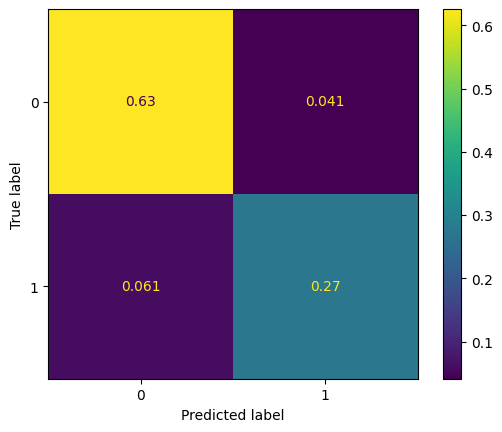

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for Logistic Regression (with oversampling)
perf_log_reg_train_set_over = model_performance(log_reg_02, X_train_over, y_train_over)
print(f'''Model Performance on training set
{perf_log_reg_train_set_over}''')

# Step 1: Generate the confusion matrix for the oversampled training set
cm = confusion_matrix(y_train_over, log_reg_02.predict(X_train_over), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The recall on the train set is fairly good of 82% and the FN in the confusion matrix shows 5.7% only which reflects a very good performance yet this performance is lower compared to the non-sampled data, yet the precision is better.

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0   0.89139  0.648649   0.666667  0.657534


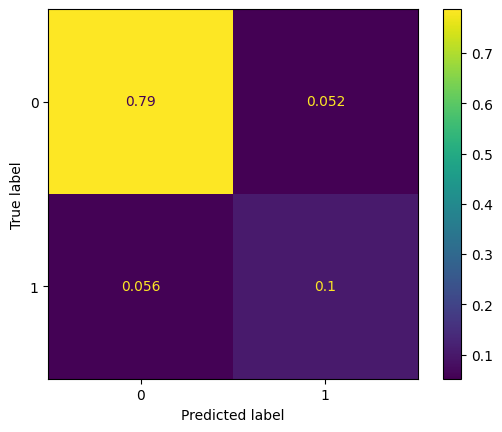

In [ ]:
#model performance evaluation on validarion set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Logistic Regression
perf_log_reg_val_set_over = model_performance(log_reg_02, X_val, y_val)
print(f'''Model Performance on validation set
{perf_log_reg_val_set_over}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, log_reg_02.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The recall on the validation set dropped significantly which reflects an overfit model.

**Decision Tree**<br>

In [ ]:
#creating the decission tree classifier by limiting the max_depth to 5 to reduce the model overfitting
model_8 = DecisionTreeClassifier(random_state=1, max_depth=5)
dTree_2 = model_8.fit(X_train_over, y_train_over)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.935474  0.890179   0.913982  0.901923


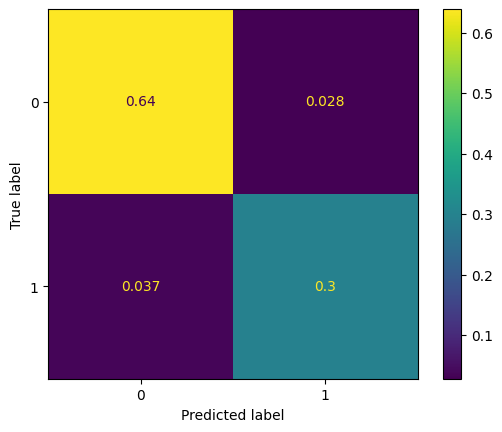

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for Decision Tree (with oversampling)
perf_dTree_train_set_over = model_performance(dTree_2, X_train_over, y_train_over)
print(f'''Model Performance on training set
{perf_dTree_train_set_over}''')

# Step 1: Generate the confusion matrix for the oversampled training set
cm = confusion_matrix(y_train_over, dTree_2.predict(X_train_over), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The recall on the train set has increased from 84% on the non-sampled data to 89% for the over sampled data. The performance is also better than the logistic regression model performance.

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.922591  0.793612   0.742529  0.767221


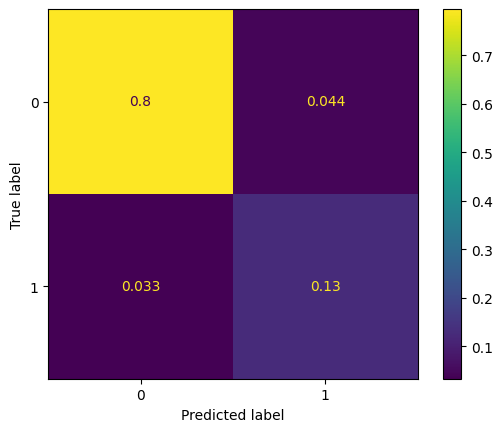

In [ ]:
#model performance evaluation on Validation set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Decision Tree
perf_dTree_val_set_over = model_performance(dTree_2, X_val, y_val)
print(f'''Model Performance on validation set
{perf_dTree_val_set_over}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, dTree_2.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the validation set is yet slightly better than the model with the non-sampled data, yet it relfects more overfitting.

**Adaboost Classifier**<br>

In [ ]:
#an adaboost classifier is creaited using the base estimatore as the logistic regression model created in model_1
#this base estimator is preferred over the default decision tree as it yielded a well performing generalized model
from sklearn.ensemble import AdaBoostClassifier

# Assuming model_1 is your base estimator (e.g., a decision tree)
model_9 = AdaBoostClassifier(estimator=model_1, random_state=1)

# Fit AdaBoost model on the oversampled training data
adaboost_2 = model_9.fit(X_train_over, y_train_over)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.808095  0.948855   0.643952  0.767221


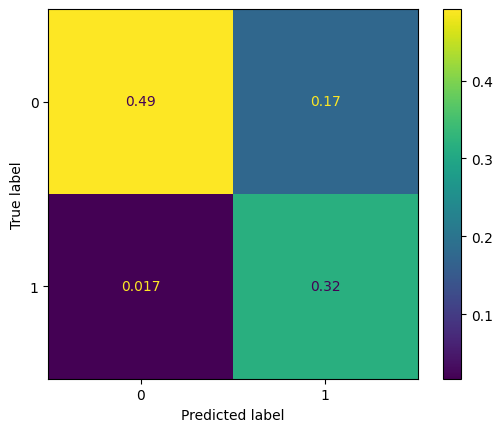

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Oversampled Training Set for AdaBoost
perf_adaboost_train_set_over = model_performance(adaboost_2, X_train_over, y_train_over)
print(f'''Model Performance on training set
{perf_adaboost_train_set_over}''')

# Step 1: Generate the confusion matrix for the oversampled training set
cm = confusion_matrix(y_train_over, adaboost_2.predict(X_train_over), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance is better than logistic regression model and decision tree and also better than the Adaboost model on the non-sampled data.

Model Performance on validation set 
   Accuracy    Recall  Precision       F1
0  0.774092  0.899263   0.408027  0.56135


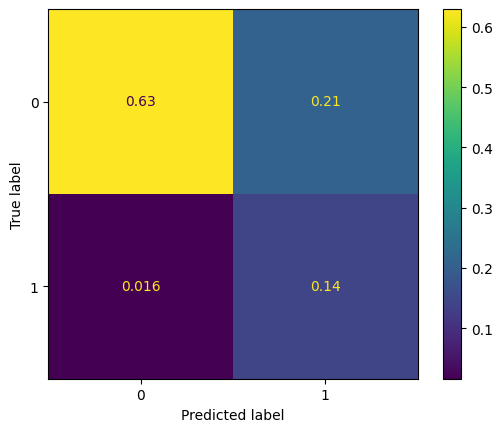

In [ ]:
#model performance evaluation on val set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for AdaBoost
perf_adaboost_val_set_over = model_performance(adaboost_2, X_val, y_val)
print(f'''Model Performance on validation set
{perf_adaboost_val_set_over}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, adaboost_2.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

A very good performance is observed on the validation set with slight overfitting which means the model is generalized and robust. Thus far, the Adaboost model is a better performing and generalized model than Decision tree and logistic regresson on the over-sampled data. It is very close to the XGBoost performance on the non-sampled data.

**Gredient Boosting Classifier**<br>

In [ ]:
#creating a Gradient boosting classifier model using the Logistic regression model_1 as its init parameter
model_10 = GradientBoostingClassifier(init = model_1, random_state=1)
gboost_2 = model_10.fit(X_train_over, y_train_over)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.978456  0.960778   0.974228  0.967457


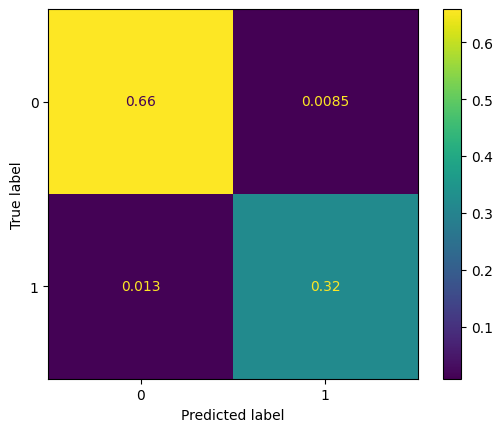

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Oversampled Training Set for Gradient Boosting
perf_gboost_train_set_over = model_performance(gboost_2, X_train_over, y_train_over)
print(f'''Model Performance on training set
{perf_gboost_train_set_over}''')

# Step 1: Generate the confusion matrix for the oversampled training set
cm = confusion_matrix(y_train_over, gboost_2.predict(X_train_over), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance is very good, the recall is higher than all recalls derived from adaboost and logistic regression and Decision tree. The FN ratio is also lower, yet its performance is very close to the oversampled trained model

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.963665  0.845209   0.922252  0.882051


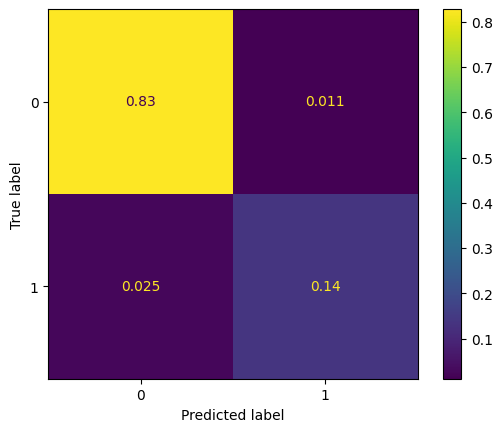

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Gradient Boosting
perf_gboost_val_set_un = model_performance(gboost_2, X_val, y_val)
print(f'''Model Performance on validation set
{perf_gboost_val_set_un}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, gboost_2.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the validation set shows that the model is less overfitting than the model trained on the oversampled data. Hence, this model is the best performing and genaralized model compared tp the non-sampled and over-sampled trained GBoost models.

**XGBoost Classifier**<br>

In [ ]:
#creating an XGBoost classifier with eval_metric:logloss and max_depth=3 to minimize the overfitting
model_11 = XGBClassifier(random_state=1, eval_metric='logloss', max_depth=3)
xgb_2 = model_11.fit(X_train_over,y_train_over)

Model Performance on training set 
   Accuracy    Recall  Precision       F1
0  0.990274  0.982742   0.988013  0.98537


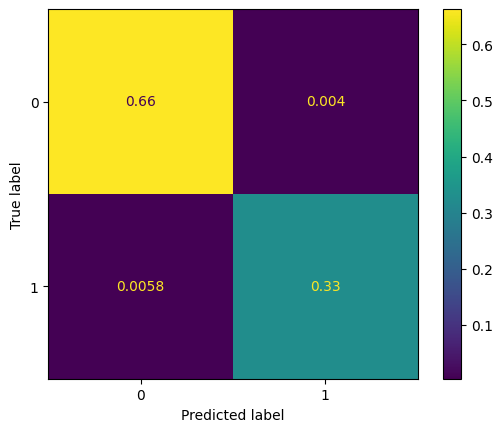

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Oversampled Training Set for XGBoost
perf_xgboost_train_set_over = model_performance(xgb_2, X_train_over, y_train_over)
print(f'''Model Performance on training set
{perf_xgboost_train_set_over}''')

# Step 1: Generate the confusion matrix for the oversampled training set
cm = confusion_matrix(y_train_over, xgb_2.predict(X_train_over), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the train set is very good and very close to the recall observed on the GBoost model. It also shows a much smaller FN Ratio. The Precision and accuracy are also very high.

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.971959  0.894349   0.928571  0.911139


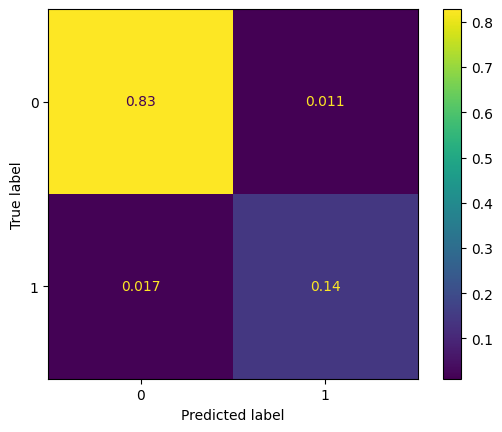

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for XGBoost
perf_xgboost_val_set_over = model_performance(xgb_2, X_val, y_val)
print(f'''Model Performance on validation set
{perf_xgboost_val_set_over}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, xgb_2.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The performance dropped on the validation set slightly which means a slight overfit yet the model is more generalized and better performing than the XGBoost models trained on non-sampled and over-sampled data.

**Stacking Classifier**<br>

In [ ]:
estimators = [('Logistic regression',log_reg_02), ('Decision Tree',dTree_2), ('Ada Boost',adaboost_2),
              ('Gboost',xgb_2)]
final_estimator = gboost_2
model_18= StackingClassifier(estimators=estimators,final_estimator=final_estimator)
stacking_classifier_3 = model_18.fit(X_train,y_train)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.977306  0.942579   0.988808  0.965141


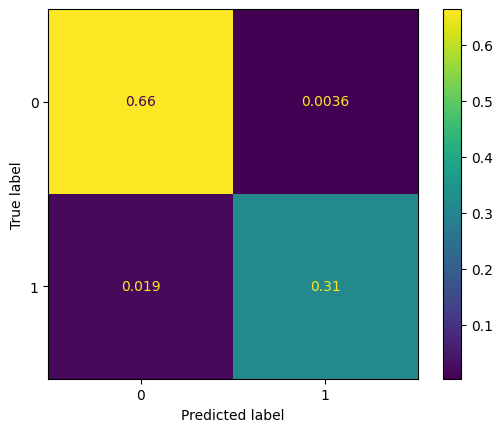

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Oversampled Training Set for Stacking Classifier
perf_stacking_train_set_over = model_performance(stacking_classifier_3, X_train_over, y_train_over)
print(f'''Model Performance on training set
{perf_stacking_train_set_over}''')

# Step 1: Generate the confusion matrix for the oversampled training set
cm = confusion_matrix(y_train_over, stacking_classifier_3.predict(X_train_over), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the train set is very close to the Adaboost model which is slightly lower than the recall observed with XGBoost and GBoost. It is also slightly less than the performance observed with the non-sampled data.

Model Performance on validation set 
   Accuracy    Recall  Precision    F1
0  0.971564  0.894349   0.926209  0.91


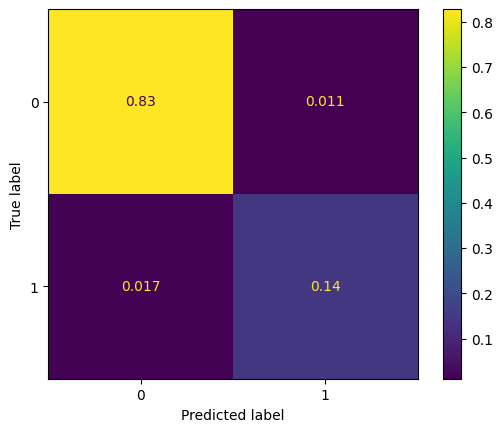

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Stacking Classifier
perf_stacking_val_set_over = model_performance(stacking_classifier_3, X_val, y_val)
print(f'''Model Performance on validation set
{perf_stacking_val_set_over}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, stacking_classifier_3.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

The model performance on the train set is very close to the Stacking model trained on the oversampled and the non-sampled data. It is less compared to the XGBoost model.

In [ ]:
models_2 = ['Logistic Regression', 'Decision Tree', 'AdaBoost', 'Gradient Boost', 'XGBoost', 'Stacking']

# Concatenating training performance
perf_gboost_val_set_over = model_performance(gboost_2, X_val, y_val)
models_train_perf_over = pd.concat([perf_log_reg_train_set_over,
                                    perf_dTree_train_set_over,
                                    perf_adaboost_train_set_over,
                                    perf_gboost_train_set_over,
                                    perf_xgboost_train_set_over,
                                    perf_stacking_train_set_over], axis=0)

models_train_perf_over.set_index([pd.Index(models_2)], inplace=True)

# Concatenating validation performance
models_val_perf_over = pd.concat([perf_log_reg_val_set_over,
                                  perf_dTree_val_set_over,
                                  perf_adaboost_val_set_over,
                                  perf_gboost_val_set_over,
                                  perf_xgboost_val_set_over,
                                  perf_stacking_val_set_over], axis=0)

models_val_perf_over.set_index([pd.Index(models_2)], inplace=True)

# Combining both training and validation performances for comparison
all_models_over = pd.concat([models_train_perf_over.add_suffix('_Train'),
                             models_val_perf_over.add_suffix('_Val')], axis=1)

print("Training performance VS Validation performance comparison with Over-Sampled Train Data:")
all_models_over

Training performance VS Validation performance comparison with Over-Sampled Train Data:


,Accuracy_Train,Recall_Train,Precision_Train,F1_Train,Accuracy_Val,Recall_Val,Precision_Val,F1_Val
Logistic Regression,0.897929,0.817383,0.868623,0.842224,0.891390,0.648649,0.666667,0.657534
Decision Tree,0.935474,0.890179,0.913982,0.901923,0.922591,0.793612,0.742529,0.767221
AdaBoost,0.808095,0.948855,0.643952,0.767221,0.774092,0.899263,0.408027,0.561350
Gradient Boost,0.978456,0.960778,0.974228,0.967457,0.963665,0.845209,0.922252,0.882051
XGBoost,0.990274,0.982742,0.988013,0.985370,0.971959,0.894349,0.928571,0.911139
Stacking,0.977306,0.942579,0.988808,0.965141,0.971564,0.894349,0.926209,0.910000


**Hyperparameter tuning using random search**<br>

Comparing all previous 18 models, the best 3 models moving forward to the hyper-parameter tuning are:

- Model 15: Adabost with undersampled data
- Model 16: GBoost with undersampled data
- model 17: XGBoost with Undersampled data

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
perf_adaboost_val_set_un = model_performance(adaboost_2, X_val, y_val)
# Assuming xgb_2 is your XGBoost model trained on the undersampled data
perf_xgboost_val_set_un = model_performance(xgb_2, X_val, y_val)
# Assuming gboost_2 is your Gradient Boosting model trained on the undersampled data
perf_gboost_val_set_un = model_performance(gboost_2, X_val, y_val)
# Create undersampled training data
undersampler = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = undersampler.fit_resample(X_train, y_train)

# Compute the AdaBoost performance on undersampled training set
perf_adaboost_train_set_un = model_performance(adaboost_2, X_train_un, y_train_un)

# Similarly, calculate performance for Gradient Boost and XGBoost if not already done
perf_gboost_train_set_un = model_performance(gboost_2, X_train_un, y_train_un)
perf_xgboost_train_set_un = model_performance(xgb_2, X_train_un, y_train_un)

# Continue with concatenating the model performance
models_to_tune = ['AdaBoost', 'Gradient Boost', 'XGBoost']

# Concatenating training performance for the models to tune
train_perf_to_tune = pd.concat([
    perf_adaboost_train_set_un,
    perf_gboost_train_set_un,
    perf_xgboost_train_set_un], axis=0)

train_perf_to_tune.set_index([pd.Index(models_to_tune)], inplace=True)

# Concatenating validation performance for the models to tune
val_perf_un = pd.concat([
    perf_adaboost_val_set_un,
    perf_gboost_val_set_un,
    perf_xgboost_val_set_un], axis=0)

val_perf_un.set_index([pd.Index(models_to_tune)], inplace=True)

# Adding suffixes for training and validation performance
to_tune_models = pd.concat([train_perf_to_tune.add_suffix('_Train'),
                            val_perf_un.add_suffix('_Val')], axis=1)

print("Training performance VS Validation performance comparison with the best 3 models to tune:")
to_tune_models

Training performance VS Validation performance comparison with the best 3 models to tune:


,Accuracy_Train,Recall_Train,Precision_Train,F1_Train,Accuracy_Val,Recall_Val,Precision_Val,F1_Val
AdaBoost,0.832377,0.918852,0.783368,0.845719,0.774092,0.899263,0.408027,0.561350
Gradient Boost,0.946721,0.905738,0.986607,0.944444,0.963665,0.845209,0.922252,0.882051
XGBoost,0.974590,0.956557,0.992347,0.974124,0.971959,0.894349,0.928571,0.911139


Training performance VS Validation performance comparison with the best 3 models to tune:

**Tuning Adaboost**<br>

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=1)
parameters = {
    #Let's try different max_depth for base_estimator
    "base_estimator":[DecisionTreeClassifier(max_depth=1),DecisionTreeClassifier(max_depth=2),
                      DecisionTreeClassifier(max_depth=3),DecisionTreeClassifier(max_depth=5),
                      DecisionTreeClassifier(max_depth=7)],
    "n_estimators": np.arange(10,150,10),
    "learning_rate":np.arange(0.1,2,0.1)
}
randomized_cv = RandomizedSearchCV(estimator=adaboost, param_distributions=parameters, n_iter=10, random_state=1, cv=5)
model_15 = AdaBoostClassifier(random_state=1 )
# Step 1: Train the XGBoost model on the undersampled training data
xgb_2 = XGBClassifier(random_state=1)
xgb_2.fit(X_train_un, y_train_un)

# Step 2: Evaluate the XGBoost model on the validation set
perf_xgboost_val_set_un = model_performance(xgb_2, X_val, y_val)

scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model_15,
    param_distributions=parameters,
    n_iter=40,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
#randomized_cv.fit(param_distributions, scoring)

print(
   "Best parameters are {} with CV score={}:".format(
      randomized_cv.estimator, randomized_cv.param_distributions
   )
)

Best parameters are AdaBoostClassifier(random_state=1) with CV score={'base_estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2), DecisionTreeClassifier(max_depth=3), DecisionTreeClassifier(max_depth=5), DecisionTreeClassifier(max_depth=7)], 'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140]), 'learning_rate': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
       1.4, 1.5, 1.6, 1.7, 1.8, 1.9])}:


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Create the AdaBoost model with the tuned parameters
model_15_tuned = AdaBoostClassifier(
    n_estimators=80,
    learning_rate=0.2,
    estimator=DecisionTreeClassifier(max_depth=3),  # Use 'estimator' instead of 'base_estimator'
    random_state=1
)

# Fit the tuned model on the undersampled training data
Adaboost_tuned = model_15_tuned.fit(X_train_un, y_train_un)

Model Performance on training set 
   Accuracy   Recall  Precision        F1
0  0.998361  0.99918   0.997545  0.998362


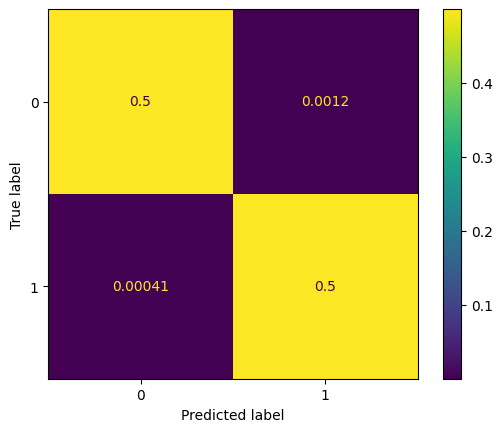

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for Tuned AdaBoost Model
perf_ada_tuned_train_set = model_performance(Adaboost_tuned, X_train_un, y_train_un)
print(f'''Model Performance on training set
{perf_ada_tuned_train_set}''')

# Step 1: Generate the confusion matrix for the training set
cm = confusion_matrix(y_train_un, Adaboost_tuned.predict(X_train_un), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.945893  0.948403   0.768924  0.849285


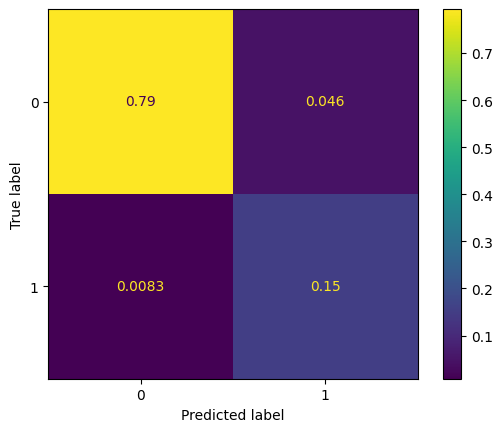

In [ ]:
#model performance evaluation on val set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Tuned AdaBoost Model
perf_ada_tuned_val_set = model_performance(Adaboost_tuned, X_val, y_val)
print(f'''Model Performance on validation set
{perf_ada_tuned_val_set}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, Adaboost_tuned.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

**Tuning Gradient Boost**<br>

In [ ]:
model_16 = GradientBoostingClassifier(init = LogisticRegression(random_state=1, solver = 'newton-cg'), random_state=1)

# Parameter grid to pass in RandomizedSearchCV
# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(10,150,10),
    "subsample":np.arange(0.8,0.9,0.1),
    "max_features":np.arange(0.3,1,0.1)
}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model_16,
    param_distributions=parameters,
    n_iter=40,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)

Best parameters are {'subsample': 0.8, 'n_estimators': 130, 'max_features': 0.5} with CV score=0.9565573770491802:


In [ ]:
#creating a new model with the tuned parameter
model_16_tuned =  GradientBoostingClassifier(init=model_1, subsample= 0.8,
                                             n_estimators=140, max_features= 0.4, random_state=1 )
gboost_tuned = model_16_tuned.fit(X_train_un, y_train_un)

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.983197  0.986885   0.979658  0.983258


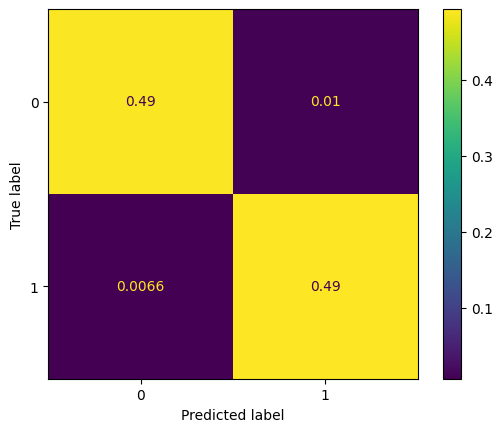

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for Tuned Gradient Boosting Model
perf_gboost_tuned_train_set = model_performance(gboost_tuned, X_train_un, y_train_un)
print(f'''Model Performance on training set
{perf_gboost_tuned_train_set}''')

# Step 1: Generate the confusion matrix for the training set
cm = confusion_matrix(y_train_un, gboost_tuned.predict(X_train_un), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.952212  0.943489    0.79668  0.863892


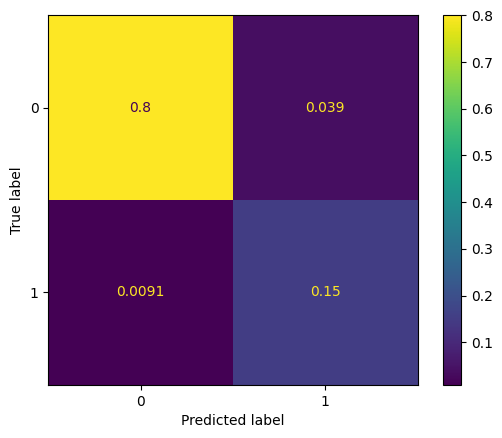

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Tuned Gradient Boosting Model
perf_gboost_tuned_val_set = model_performance(gboost_tuned, X_val, y_val)
print(f'''Model Performance on validation set
{perf_gboost_tuned_val_set}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, gboost_tuned.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

**Tuning XGBoost**<br>

In [ ]:
model_17 = XGBClassifier(random_state=1, eval_metric='logloss')

# Parameter grid to pass in RandomizedSearchCV
# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(10,50,10),
    "scale_pos_weight":np.arange(1,5,1),
    "subsample":np.arange(0.3,1,0.1),
    "learning_rate":np.arange(0.05, 0.1,0.01),
    "colsample_bytree":np.arange(0.3,1,0.1),
    "colsample_bylevel":np.arange(0.3,0.9,0.1)
}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model_17,
    param_distributions=parameters,
    n_iter=40,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)

Best parameters are {'subsample': 0.7000000000000002, 'scale_pos_weight': 3, 'n_estimators': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7000000000000002, 'colsample_bylevel': 0.9000000000000001} with CV score=1.0:


In [ ]:
#creating a new model with the tuned parameter
model_17_tuned =  XGBClassifier(subsample=0.7, scale_pos_weight = 4,
                                             n_estimators= 40, learning_rat= 0.06,
                                             colsample_bytree= 0.9, colsample_bylevel= 0.7,
                                             random_state=1, eval_metric='logloss')
xgboost_tuned = model_17_tuned.fit(X_train_un, y_train_un)

Model Performance on training set 
   Accuracy  Recall  Precision        F1
0  0.995902     1.0    0.99187  0.995918


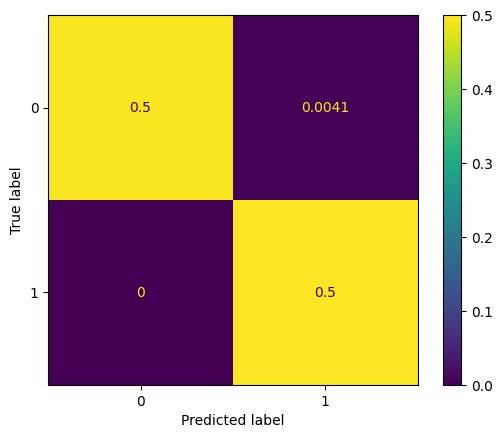

In [ ]:
#model performance evaluation on train set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for Tuned XGBoost Model
perf_xgboost_tuned_train_set = model_performance(xgboost_tuned, X_train_un, y_train_un)
print(f'''Model Performance on training set
{perf_xgboost_tuned_train_set}''')

# Step 1: Generate the confusion matrix for the training set
cm = confusion_matrix(y_train_un, xgboost_tuned.predict(X_train_un), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

Model Performance on validation set 
   Accuracy    Recall  Precision        F1
0  0.938389  0.968059   0.733706  0.834746


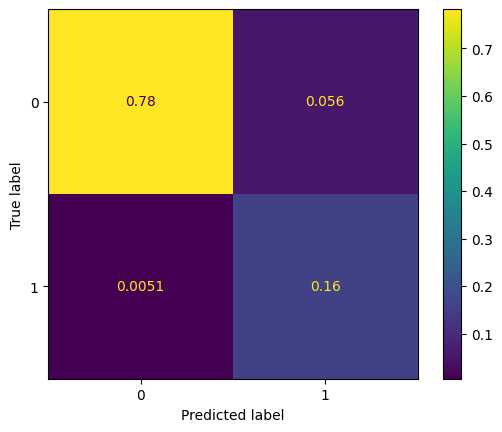

In [ ]:
#model performance evaluation on val set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Validation Set for Tuned XGBoost Model
perf_xgboost_tuned_val_set = model_performance(xgboost_tuned, X_val, y_val)
print(f'''Model Performance on validation set
{perf_xgboost_tuned_val_set}''')

# Step 1: Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, xgboost_tuned.predict(X_val), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

Model Performance on test set 
   Accuracy    Recall  Precision        F1
0  0.937315  0.969231   0.729167  0.832232


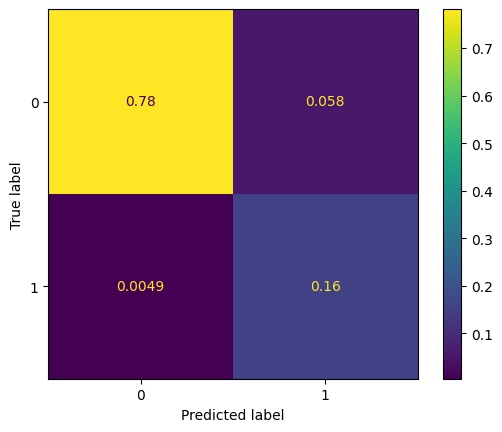

In [ ]:
#model performance evaluation on test set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Test Set for Tuned XGBoost Model
perf_xgboost_tuned_test_set = model_performance(xgboost_tuned, X_test, y_test)
print(f'''Model Performance on test set
{perf_xgboost_tuned_test_set}''')

# Step 1: Generate the confusion matrix for the test set
cm = confusion_matrix(y_test, xgboost_tuned.predict(X_test), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

**Model Performances**<br>

- Compare the model performance of tuned models - Choose the best model


In [ ]:
models_tuned = ['AdaBoost_tuned','Gradient Boost_tuned','XGBoost_tuned']

train_perf_tuned= pd.concat([
perf_ada_tuned_train_set,
perf_gboost_tuned_train_set,
perf_xgboost_tuned_train_set],axis=0)

train_perf_tuned.set_index([pd.Index(models_tuned)], inplace=True)


val_perf_tuned = pd.concat([
perf_ada_tuned_val_set,
perf_gboost_tuned_val_set,
perf_xgboost_tuned_val_set],axis=0)

val_perf_tuned.set_index([pd.Index(models_tuned)], inplace=True)

print("Training performance VS Validation performance comparison with the best 3 models to tune:")

tuned_models = pd.concat([train_perf_tuned,val_perf_tuned],axis=1 )
tuned_models

Training performance VS Validation performance comparison with the best 3 models to tune:


,Accuracy,Recall,Precision,F1,Accuracy,Recall,Precision,F1
AdaBoost_tuned,0.998361,0.999180,0.997545,0.998362,0.945893,0.948403,0.768924,0.849285
Gradient Boost_tuned,0.983197,0.986885,0.979658,0.983258,0.952212,0.943489,0.796680,0.863892
XGBoost_tuned,0.995902,1.000000,0.991870,0.995918,0.938389,0.968059,0.733706,0.834746


**Conclusion:**<br>

- The Tuned XGBoost model perfromance is showing the best recall on the validation set. Yet, the GBoost model is showing the least overfitting. Hence, based on the performance, the model moving on to the production is the XGBoost_tuned model.

**Feature importance for tuned GBoost model**<br>


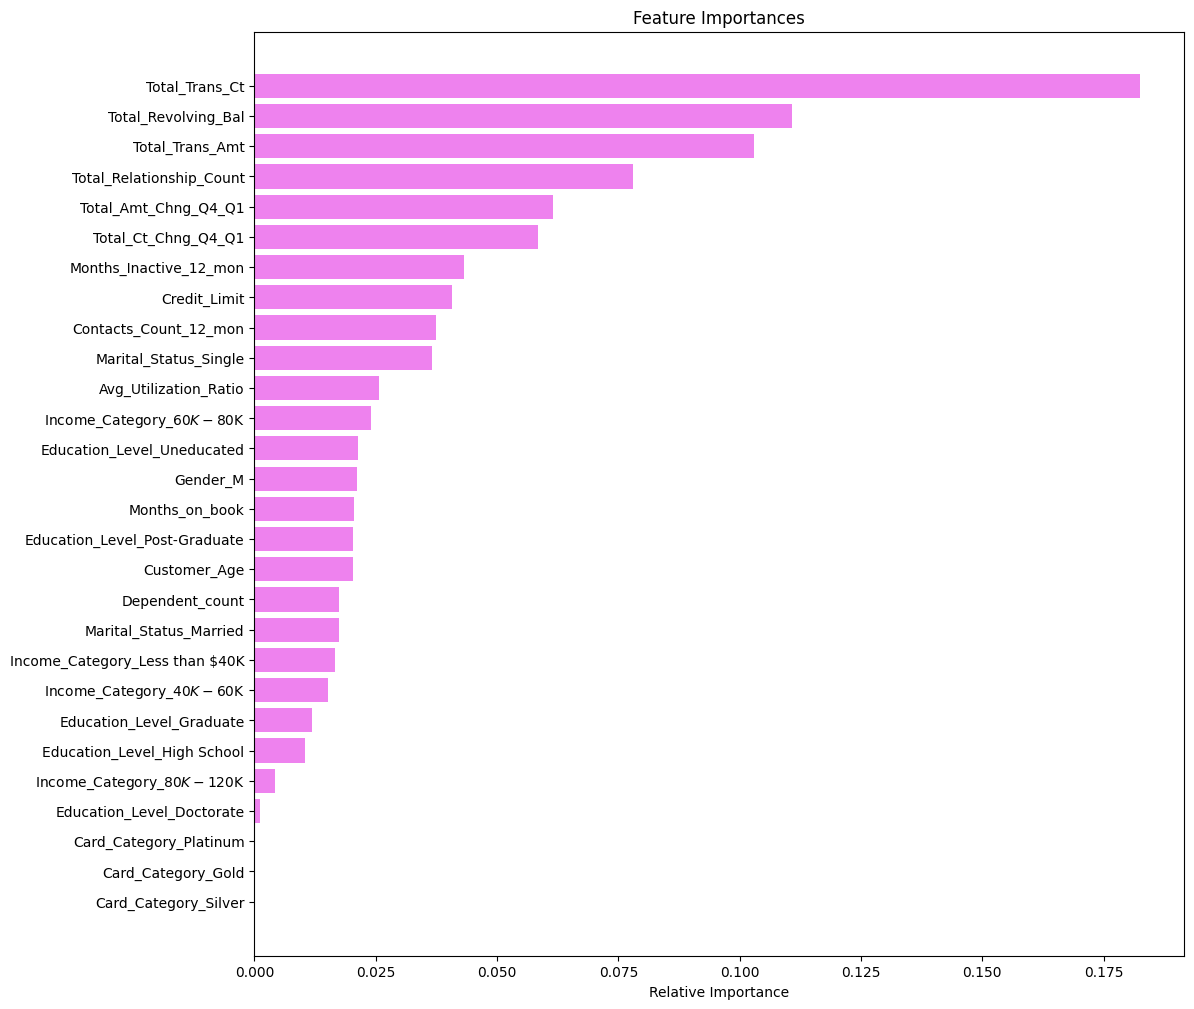

In [ ]:
feature_names = X_train.columns
importances = xgboost_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

- As observed during the EDA, four of the strongest predictors are confirmed by the final model + 1 of the medium predictors:

1. Total_Trans_Ct
2. Total_Trans_Amt
3. Total_Revolving_Bal
4. Total_Ct_Chng_Q4_Q1
5. Total_Relationship_count

**Productionize the model**<br>

Now, as we have a final model we will use pipelines to put the model into production. We will start by creating a column transformer pipeline to handle any missing values in numercial and categorical variables, in addition to performing one hot encoding on the categorical variables. Last step is creating the final pipeline with the model and fitting it to the train data and finally observing the performance on the test set.

**1. Column Transformer**<br>

In [ ]:
#we will import the make_column_selector to apply the imputers on each the numerical and categorical variables
from sklearn.compose import make_column_selector as selector

In [ ]:
#creating the numerical transformer using the sipmle imputer with strategy "median" and applying a standard scaler
numerical_transformer = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

#creating the categorical transformer using the sipmle imputer with strategy "most_frequent"
categorical_transformer= make_pipeline(SimpleImputer(strategy="most_frequent"),
                                      OneHotEncoder(handle_unknown="ignore"))

#creating the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, selector(dtype_exclude="category")),
        ('cat', categorical_transformer, selector(dtype_include="category"))
    ],
    remainder="passthrough",
)

**2. Separating target variable and other variables**<br>

In [ ]:
X = df.drop(columns="Attrition_Flag",axis=1)
y= df["Attrition_Flag"].replace(['Existing Customer','Attrited Customer'],[0,1])

#replacing the junk value with NaN
X['Income_Category'] = X['Income_Category'].replace('abc', np.NaN)

#converting the objects into category
for i in categorical:
    X[i] = X[i] .astype('category')

**3. Splitting the data to train and test**<br>

As we already know the best model we need to process with, so we don't need to divide data into 3 sets - train, validation and test

In [ ]:
#splitting the data into train and test via 70:30 ratio.
from sklearn.model_selection import train_test_split

# Splitting the data into train and test sets with a 70:30 ratio
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# Print the shape of the train and test sets
print(X_train_final.shape, X_test_final.shape)

(7088, 18) (3039, 18)


**4. Creating the final pipeline with the model**<br>

In [ ]:
model = make_pipeline(preprocessor,XGBClassifier(subsample=0.7, scale_pos_weight = 4,
                                             n_estimators= 40, learning_rat= 0.06,
                                             colsample_bytree= 0.9, colsample_bylevel= 0.7,
                                            random_state=1, eval_metric='logloss'))

In [ ]:
#fitting the model on the training set
model.fit(X_train_final, y_train_final)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c57792af460>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy=...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rat=0.06,
                               learning_rate=None, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=None,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=40,
                               n_jobs=None, num_parallel_tree=None, ...))])

Model Performance on training set 
   Accuracy    Recall  Precision        F1
0  0.994074  0.999122   0.965225  0.981881


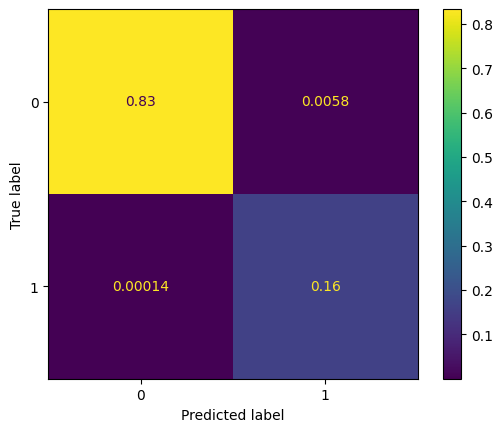

In [ ]:
#model performance evaluation on training set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Training Set for the Final Model
final_train_set = model_performance(model, X_train_final, y_train_final)
print(f'''Model Performance on training set
{final_train_set}''')

# Step 1: Generate the confusion matrix for the training set
cm = confusion_matrix(y_train_final, model.predict(X_train_final), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

Model Performance on test set 
   Accuracy    Recall  Precision        F1
0  0.971043  0.940574     0.8861  0.912525


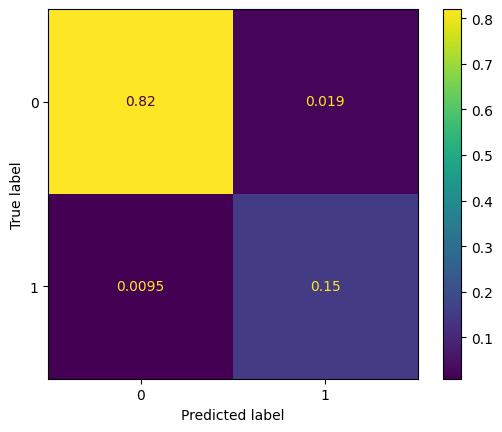

In [ ]:
#model performance evaluation on test set
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Model Performance Evaluation on Test Set for the Final Model
final_test_set = model_performance(model, X_test_final, y_test_final)
print(f'''Model Performance on test set
{final_test_set}''')

# Step 1: Generate the confusion matrix for the test set
cm = confusion_matrix(y_test_final, model.predict(X_test_final), normalize='all')

# Step 2: Display the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

**Actionable Insights & Recommendations**<br>

**Business insights:**<br>


The Univarate Analysis shows the below common characteristics among customers:
- 16.1% of the customers as Attrited and 83.9% as existing
- 53% of the client base are females
- 93% carry the Blue card
- 35% belong to the Income_category less than USD 40K
- 46% of customers are married
-
The Bivariate Analysis showed:

- The Credit_Limit and Avg_Open_To_Buy variables are very strongy correlated
- The Total_Trans_Amt and Total_Trans_Ct variables are strongly correlated
- The Strong Predictors and their Relation ship between variables and target variable are:
1. Attrited customers have less Total_Revolving_Bal,Total_Trans_Ct, Total_Trans_Amt,Total_Ct_Chng_Q4_Q1 and Total_Relationship_Count than Existing customers
2. Card_Category shows The highest ratio of Attrited customers as Platinum card holders.30% are graduates


**Classification model sum up:**<br>
- The algorithm applied to derive the final classifiction is XGBoost model with its hyperparameter tuned using Randomized Search

- The final model assures 92% prediction rate of the customers willing to churn with an accuracy of 97% with only 1.2% missclassified attrited customers and 1.5% of missclassification on the existing customers.

**Recommendation:**<br>

- The top 5 features deriving the the customer to Churn are stated in the table below. Hence, it is recommended to follow up closely on how these features vary with every customer in order to approach the high-risk customers on the right time to understand on the dissatisfaction reasons and have a strategy in place to attain them such as: pitching an attractive promotional offer.

|Rank|Prediction Power|Predictor|Description |--|:---:|:----|:---| |1|Strong|Total_Trans_Ct|Almost lower by half for attrited customers (median value of: 43)| |2|Strong|Total_Trans_Amt|Almost lower by half for attrited customers (median value of:2329)| |3|Strong|Total_Revolving_Bal|Much lower value observed for attrited customers(median value of: 0)| |4|Strong|Total_Ct_Chng_Q4_Q1|Almost lower by 20% for attrited customers(median value of:0.531)| |5|Strong|Total_Relationship_Count|Lower count observed for attrited customers(median value of: 3)|

- The model is also giving a strong preditcion on the existing customers, this can be utilized to explore closely the existing customers and the services they are satisfied with and enhancing them as a measure of strengthening the relationship and avoiding less to chrun in the future.